In [ ]:
import analyze_precip as ap
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import cartopy, cartopy.crs as ccrs
import seaborn as sns
import importlib
import cftime
import xarray as xr
from scipy.stats import skew

## offload data

In [ ]:
# try to offload data
importlib.reload(ap)

GW = 1

if GW == 1:
    initialpath = "WARMING_MODEL_PATH"
    fenum = 1
elif GW == 0:
    initialpath = "NONWARMING_MODEL_PATH"
    fenum = 6

ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(9,11)]
yearranges = [np.arange(year, year+10) for year in np.arange(1871, 2021, 10)] #15 total plots

for ennum in ennums:
    # collect data for each year
    for index, yearrange in enumerate(yearranges):
        print(f"{yearrange}")
        print(f"{ennum}")
        track_df = ap.load_trackdf(initialpath, yearrange, [ennum])
        track_df.to_pickle(f"trackdf_GW_en{ennum}_{yearrange[0]}{yearrange[-1]}.pkl")

## Auxiliary Functions

### get LMI dfs

In [2]:
def risplit_dfs(track_df):
    #track_df = pd.read_pickle(filename)
    
    # calculate 24-hour acceleration
    track_df['acceleration_24'] = track_df.groupby('storm_id')['max_wind'].diff(periods=4)
    
    # identify RI/non-RI storm ids
    catch_df = track_df[track_df['acceleration_24'] > 18] # RI: +18 m/s within 24 hours
    ristorms = catch_df['storm_id'].unique()
    
    nonstorms = []
    for k in track_df['storm_id'].unique():
        if k in ristorms:
            continue
        else:
            nonstorms.append(k)

    assert len(track_df['storm_id'].unique()) == len(ristorms) + len(nonstorms), f"error with ristorm and non-ristorm length"
    
    # create RI/non-RI storm dataframes
    ri_df = track_df[track_df['storm_id'].isin(ristorms)]
    ri_df['max_wind_kts'] = ri_df['max_wind']*1.94384
    
    nonri_df = track_df[track_df['storm_id'].isin(nonstorms)]
    nonri_df['max_wind_kts'] = nonri_df['max_wind']*1.94384

    return ri_df, nonri_df

In [3]:
def get_LMI_dfs(track_df):
    ri_df, nonri_df = risplit_dfs(track_df)

    lmi_ri_df = ri_df.groupby('storm_id')['max_wind'].max().to_frame()
    lmi_nonri_df = nonri_df.groupby('storm_id')['max_wind'].max().to_frame()

    return lmi_ri_df, lmi_nonri_df

### gabe's cmap function

In [4]:
def get_colormap_samples(number_of_samples: int,
                         colormap_name: str='viridis',
                         interval_minimum: int|float=0.1,
                         interval_maximum: int|float=0.9) -> list[str]:
    
    ''' Sample discrete points from a colormap. '''

    # Ensure colormap is valid
    assert colormap_name in matplotlib.colormaps, f'Colormap {colormap_name} not in matplotlib.colormaps.'

    # Get array points for sampling
    sampling_points = np.linspace(interval_minimum, interval_maximum, number_of_samples)
    # Get colors from colormaps using sampling points
    colors = matplotlib.colormaps[colormap_name](sampling_points)
    
    return colors

In [5]:
number_of_samples = 15
colormap_name = 'Spectral_r'
colors = get_colormap_samples(number_of_samples, colormap_name)

## Section I

### Superposed KDEs

[1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]
RI median: 58.44
 non-RI median: 37.35
RI std: 10.8
 non-RI std: 9.12
[1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]
RI median: 58.61
 non-RI median: 37.97
RI std: 10.76
 non-RI std: 9.43
[1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]
RI median: 58.65
 non-RI median: 37.83
RI std: 10.27
 non-RI std: 9.1
[1901 1902 1903 1904 1905 1906 1907 1908 1909 1910]
RI median: 58.84
 non-RI median: 37.75
RI std: 11.27
 non-RI std: 9.42
[1911 1912 1913 1914 1915 1916 1917 1918 1919 1920]
RI median: 59.85
 non-RI median: 37.7
RI std: 10.93
 non-RI std: 9.58
[1921 1922 1923 1924 1925 1926 1927 1928 1929 1930]
RI median: 58.92
 non-RI median: 37.84
RI std: 10.86
 non-RI std: 8.87
[1931 1932 1933 1934 1935 1936 1937 1938 1939 1940]
RI median: 58.89
 non-RI median: 37.55
RI std: 11.28
 non-RI std: 9.1
[1941 1942 1943 1944 1945 1946 1947 1948 1949 1950]
RI median: 58.42
 non-RI median: 37.86
RI std: 11.36
 non-RI std: 9.17
[1951 1952 1953 1954

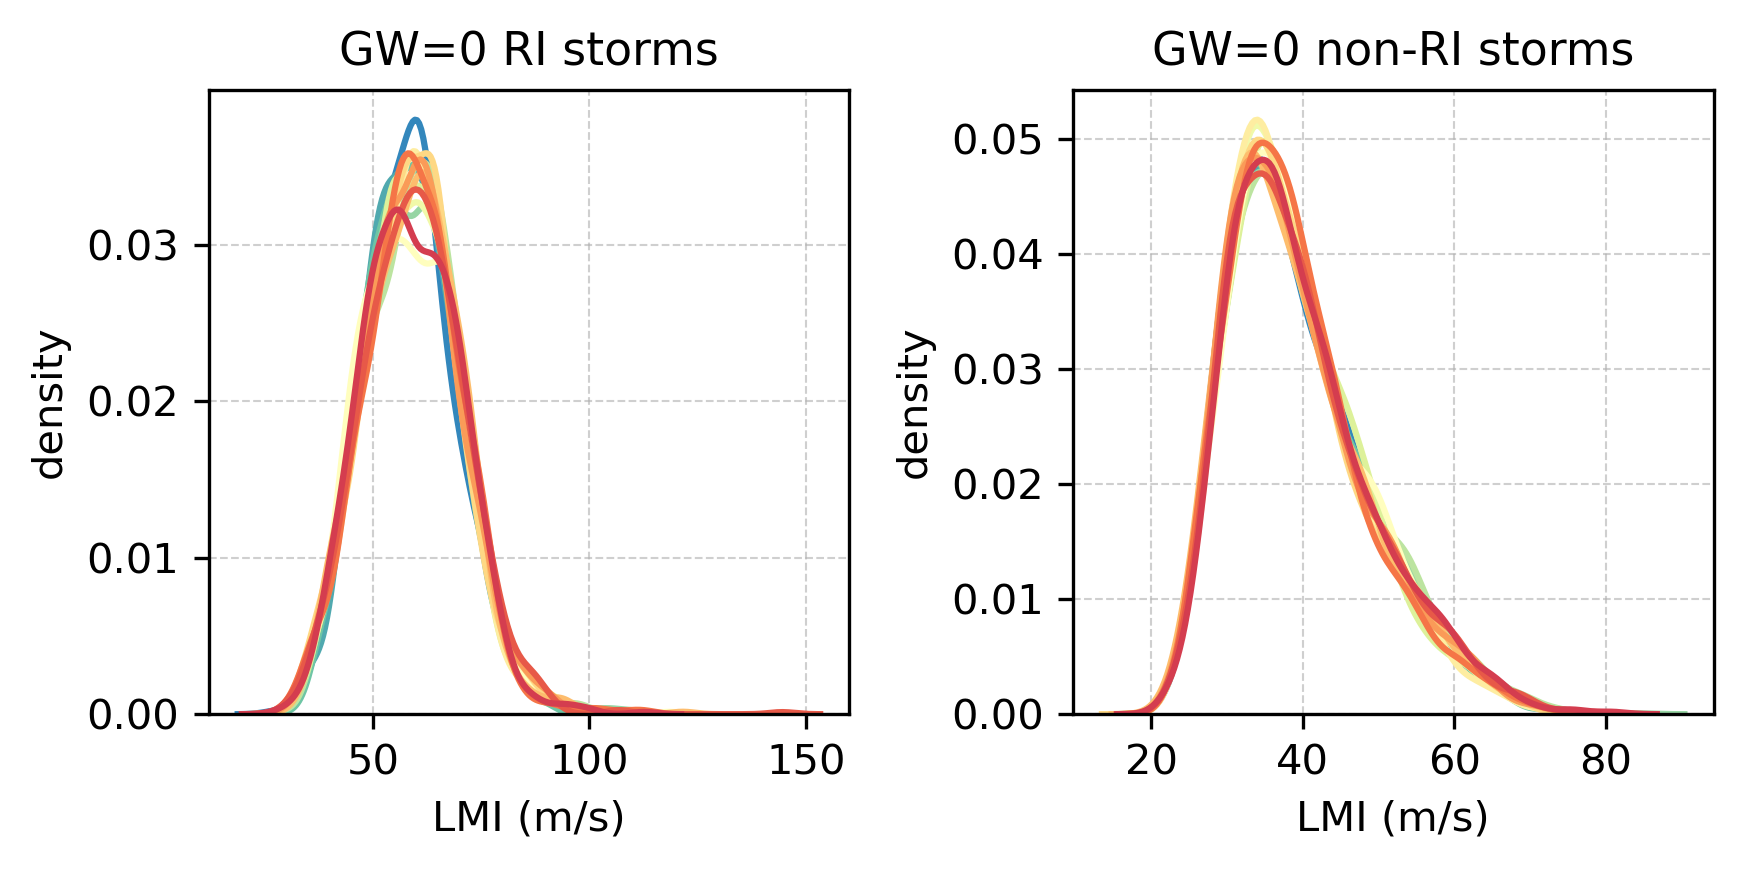

In [ ]:
# plot overlapped KDEs RI vs. non-RI for each decade
importlib.reload(ap)

numbins = 30
GW = 0
meds = np.zeros((2,15))

yearranges = [np.arange(year, year+10) for year in np.arange(1871, 2021, 10)] #15 total plots

# 2. set subplot figs
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3), dpi=300)

for index, yearrange in enumerate(yearranges):
    if GW == 0:
        filename = f"simulated_tracks/track_dfs/trackdf_NW_{yearrange[0]}{yearrange[0]+10}.pkl"
    elif GW == 1:
        filename = f"simulated_tracks/track_dfs/trackdf_GW_{yearrange[0]}{yearrange[0]+10}.pkl"

    track_df = pd.read_pickle(filename)
    lmi_ri_df, lmi_nonri_df = get_LMI_dfs(track_df)
    
    # 3. plot histograms
    dinfo = f"Y{yearrange[0]}-{yearrange[-1]}"
    axislabels = (f"LMI (m/s)",f"density")
    color = colors[index]
    
    # smooth KDEs (for CDF: cumulative=True)
    sns.kdeplot(data=lmi_ri_df, x='max_wind', cumulative=False, ax=axs[0], label=f"{dinfo} RI", color=color)
    sns.kdeplot(data=lmi_nonri_df, x='max_wind', cumulative=False, ax=axs[1], label=f"{dinfo} non-RI", color=color)
    
    # mark vertical lines
    rimed = np.median(lmi_ri_df['max_wind'])
    nonrimed = np.median(lmi_nonri_df['max_wind'])
    meds[0, index-1] = nonrimed
    meds[1, index-1] = rimed

    print(f"{yearrange}")
    print(f"RI median: {round(rimed, 2)}\n non-RI median: {round(nonrimed, 2)}")
    print(f"RI std: {round(np.std(lmi_ri_df['max_wind']),2)}\n non-RI std: {round(np.std(lmi_nonri_df['max_wind']),2)}")
    
    # -----------
    axs[0].set_title(f"GW={GW} RI storms", fontsize=11)
    axs[1].set_title(f"GW={GW} non-RI storms", fontsize=11)
    axs[0].set_xlabel(axislabels[0])
    axs[1].set_xlabel(axislabels[0])
    axs[0].set_ylabel(axislabels[1])
    axs[1].set_ylabel(axislabels[1])
    #axs[0].set_xlim((50, 90))
    #axs[1].set_xlim((50, 90))
    #axs[0].legend()
    #axs[1].legend()
    axs[0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    axs[1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

plt.tight_layout()

[1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]
RI median: 58.1
 non-RI median: 37.71
RI std: 10.82
 non-RI std: 8.96
[1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]
RI median: 58.56
 non-RI median: 37.87
RI std: 10.78
 non-RI std: 8.99
[1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]
RI median: 58.46
 non-RI median: 37.58
RI std: 11.17
 non-RI std: 9.12
[1901 1902 1903 1904 1905 1906 1907 1908 1909 1910]
RI median: 58.56
 non-RI median: 37.78
RI std: 10.9
 non-RI std: 9.25
[1911 1912 1913 1914 1915 1916 1917 1918 1919 1920]
RI median: 59.23
 non-RI median: 37.85
RI std: 10.9
 non-RI std: 9.05
[1921 1922 1923 1924 1925 1926 1927 1928 1929 1930]
RI median: 58.08
 non-RI median: 37.97
RI std: 10.59
 non-RI std: 9.31
[1931 1932 1933 1934 1935 1936 1937 1938 1939 1940]
RI median: 59.21
 non-RI median: 37.81
RI std: 10.71
 non-RI std: 9.33
[1941 1942 1943 1944 1945 1946 1947 1948 1949 1950]
RI median: 58.74
 non-RI median: 37.56
RI std: 11.38
 non-RI std: 9.18
[1951 1952 1953 195

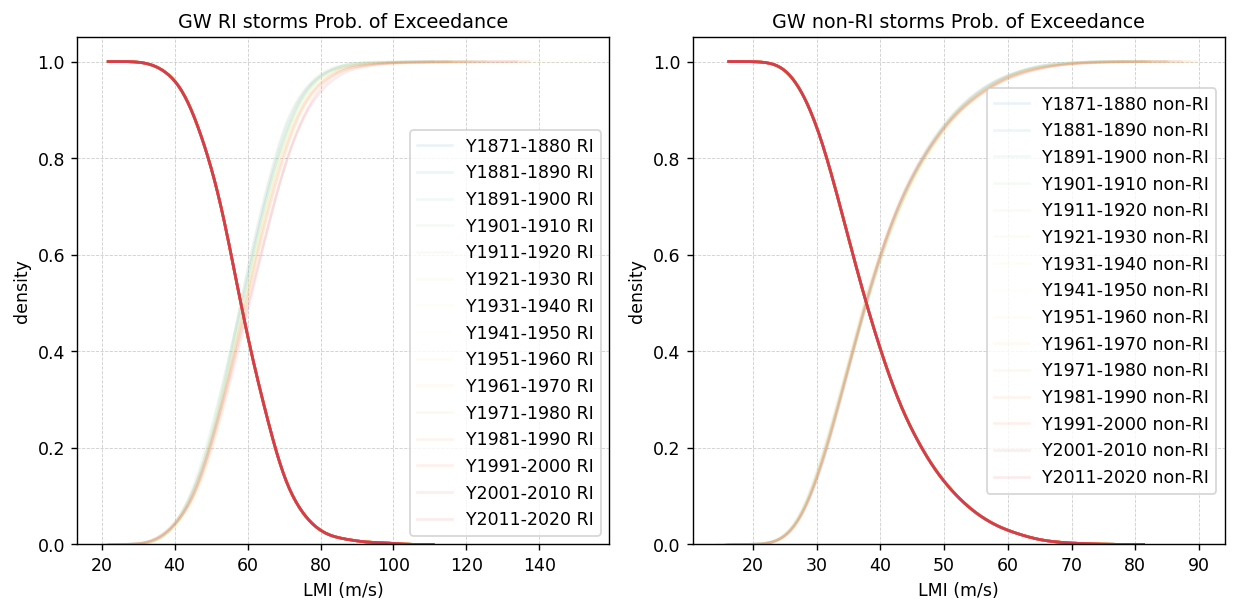

In [35]:
# 1-CDF Probability of Exceedance

importlib.reload(ap)

numbins = 30
GW = 1
meds = np.zeros((2,15))

yearranges = [np.arange(year, year+10) for year in np.arange(1871, 2021, 10)] #15 total plots

# 2. set subplot figs
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,5), dpi=125)

for index, yearrange in enumerate(yearranges):
    if GW == 0:
        filename = f"trackdf_NW_{yearrange[0]}{yearrange[0]+10}.pkl"
    elif GW == 1:
        filename = f"trackdf_GW_{yearrange[0]}{yearrange[0]+10}.pkl"

    track_df = pd.read_pickle(filename)
    lmi_ri_df, lmi_nonri_df = get_LMI_dfs(track_df)
    
    # 3. plot histograms
    dinfo = f"Y{yearrange[0]}-{yearrange[-1]}"
    axislabels = (f"LMI (m/s)",f"density")
    color = colors[index]
    
    # smooth KDEs (for CDF: cumulative=True)
    sns.kdeplot(data=lmi_ri_df, x='max_wind', cumulative=True, ax=axs[0], label=f"{dinfo} RI", color=color, alpha=0.1)
    sns.kdeplot(data=lmi_nonri_df, x='max_wind', cumulative=True, ax=axs[1], label=f"{dinfo} non-RI", color=color, alpha=0.1)

    # get line data for 1 - CDF
    ccdf_r = 1 - axs[0].lines[0].get_ydata()
    ccdf_n = 1 - axs[1].lines[0].get_ydata()

    axs[0].plot(axs[0].lines[0].get_xdata(), ccdf_r, color=color)
    axs[1].plot(axs[1].lines[0].get_xdata(), ccdf_n, color=color)

    # mark vertical lines
    rimed = np.median(lmi_ri_df['max_wind'])
    nonrimed = np.median(lmi_nonri_df['max_wind'])
    meds[0, index-1] = nonrimed
    meds[1, index-1] = rimed

    print(f"{yearrange}")
    print(f"RI median: {round(rimed, 2)}\n non-RI median: {round(nonrimed, 2)}")
    print(f"RI std: {round(np.std(lmi_ri_df['max_wind']),2)}\n non-RI std: {round(np.std(lmi_nonri_df['max_wind']),2)}")
    
    # -----------
    if GW == 0:
        axs[0].set_title(f"NW RI storms Prob. of Exceedance", fontsize=11)
        axs[1].set_title(f"NW non-RI storms Prob. of Exceedance", fontsize=11)
    elif GW == 1:
        axs[0].set_title(f"GW RI storms Prob. of Exceedance", fontsize=11)
        axs[1].set_title(f"GW non-RI storms Prob. of Exceedance", fontsize=11)
    axs[0].set_xlabel(axislabels[0])
    axs[1].set_xlabel(axislabels[0])
    axs[0].set_ylabel(axislabels[1])
    axs[1].set_ylabel(axislabels[1])
    #axs[j][i].set_ylim((0, 0.1))
    #axs[j][i].set_xlim((20, 120))
    axs[0].legend()
    axs[1].legend()
    axs[0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    axs[1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

plt.tight_layout()

[1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]
[1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]
[1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]
[1901 1902 1903 1904 1905 1906 1907 1908 1909 1910]
[1911 1912 1913 1914 1915 1916 1917 1918 1919 1920]
[1921 1922 1923 1924 1925 1926 1927 1928 1929 1930]
[1931 1932 1933 1934 1935 1936 1937 1938 1939 1940]
[1941 1942 1943 1944 1945 1946 1947 1948 1949 1950]
[1951 1952 1953 1954 1955 1956 1957 1958 1959 1960]
[1961 1962 1963 1964 1965 1966 1967 1968 1969 1970]
[1971 1972 1973 1974 1975 1976 1977 1978 1979 1980]
[1981 1982 1983 1984 1985 1986 1987 1988 1989 1990]
[1991 1992 1993 1994 1995 1996 1997 1998 1999 2000]
[2001 2002 2003 2004 2005 2006 2007 2008 2009 2010]
[2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]


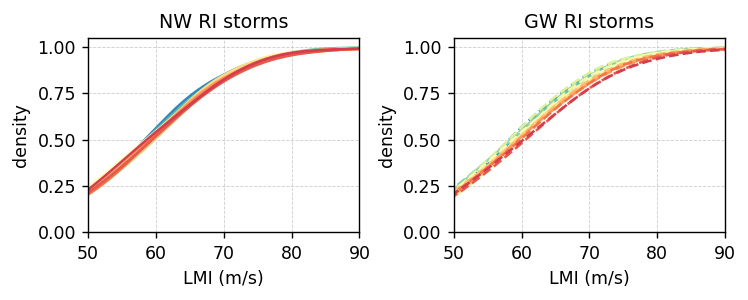

In [35]:
# plot GW x NW
numbins = 30

yearranges = [np.arange(year, year+10) for year in np.arange(1871, 2021, 10)] #15 total plots

# 2. set subplot figs
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5), dpi=125)

for index, yearrange in enumerate(yearranges):
    filename1 = f"trackdf_NW_{yearrange[0]}{yearrange[0]+10}.pkl"
    filename2 = f"trackdf_GW_{yearrange[0]}{yearrange[0]+10}.pkl"

    track_df = pd.read_pickle(filename1)
    lmi_ri_df, lmi_nonri_df = get_LMI_dfs(track_df)

    track_df2 = pd.read_pickle(filename2)
    lmi_ri_df2, lmi_nonri_df2 = get_LMI_dfs(track_df2)
    
    # 3. plot histograms
    dinfo = f"Y{yearrange[0]}-{yearrange[-1]}"
    axislabels = (f"LMI (m/s)",f"density")
    color = colors[index]
    
    # smooth KDEs (for CDF: cumulative=True)
    sns.kdeplot(data=lmi_ri_df, x='max_wind', cumulative=True, ax=axs[0], label=f"{dinfo} RI", color=color)
    sns.kdeplot(data=lmi_ri_df2, x='max_wind', cumulative=True, ax=axs[1], label=f"{dinfo} RI", color=color, linestyle='--')
    
    print(f"{yearrange}")
    # -----------
    axs[0].set_title(f"NW RI storms", fontsize=11)
    axs[1].set_title(f"GW RI storms", fontsize=11)
    axs[0].set_xlabel(axislabels[0])
    axs[1].set_xlabel(axislabels[0])
    axs[0].set_ylabel(axislabels[1])
    axs[1].set_ylabel(axislabels[1])
    axs[0].set_xlim((50, 90))
    axs[1].set_xlim((50, 90))
    #axs[0].legend()
    #axs[1].legend()
    axs[0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    axs[1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    
plt.tight_layout()

### Stacked KDE series

[1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]
RI median: 58.1
 non-RI median: 37.71
RI std: 10.82
 non-RI std: 8.96
[1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]
RI median: 58.56
 non-RI median: 37.87
RI std: 10.78
 non-RI std: 8.99
[1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]
RI median: 58.46
 non-RI median: 37.58
RI std: 11.17
 non-RI std: 9.12
[1901 1902 1903 1904 1905 1906 1907 1908 1909 1910]
RI median: 58.56
 non-RI median: 37.78
RI std: 10.9
 non-RI std: 9.25
[1911 1912 1913 1914 1915 1916 1917 1918 1919 1920]
RI median: 59.23
 non-RI median: 37.85
RI std: 10.9
 non-RI std: 9.05
[1921 1922 1923 1924 1925 1926 1927 1928 1929 1930]
RI median: 58.08
 non-RI median: 37.97
RI std: 10.59
 non-RI std: 9.31
[1931 1932 1933 1934 1935 1936 1937 1938 1939 1940]
RI median: 59.21
 non-RI median: 37.81
RI std: 10.71
 non-RI std: 9.33
[1941 1942 1943 1944 1945 1946 1947 1948 1949 1950]
RI median: 58.74
 non-RI median: 37.56
RI std: 11.38
 non-RI std: 9.18
[1951 1952 1953 195

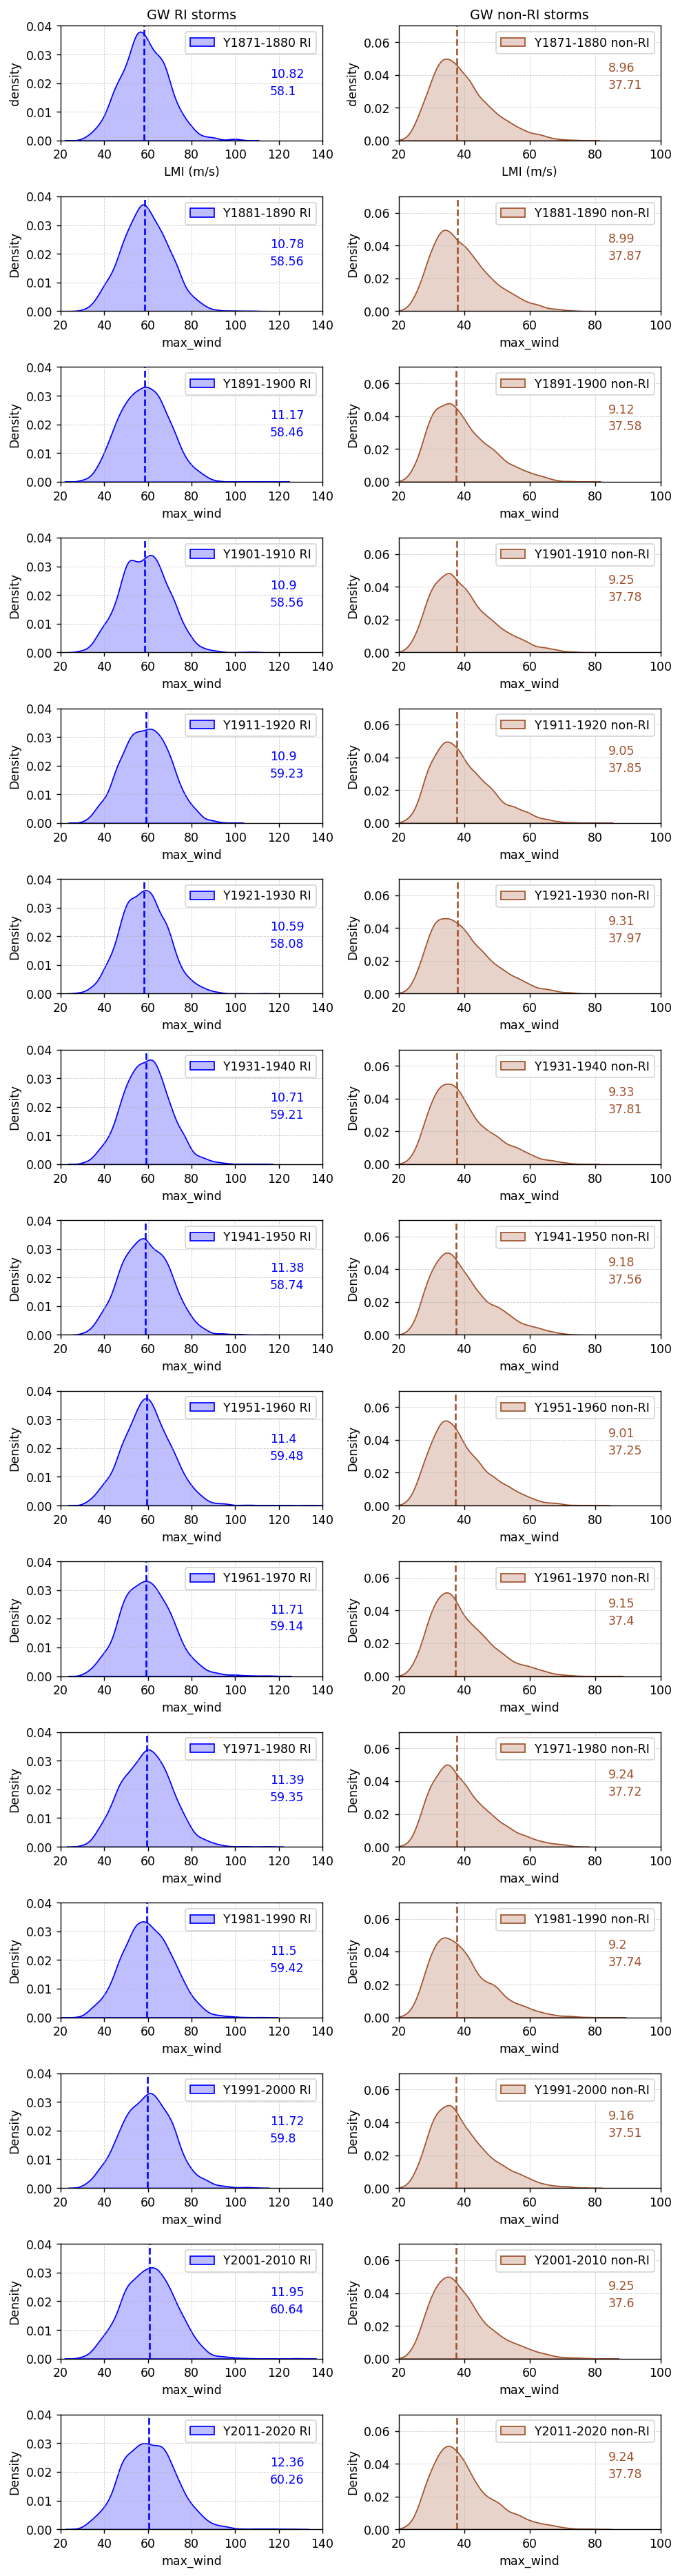

In [39]:
# display distributions in separated, stacked vertical format
importlib.reload(ap)

numbins = 30
GW = 1
meds = np.zeros((2,15))

yearranges = [np.arange(year, year+10) for year in np.arange(1871, 2021, 10)] #15 total plots
numrows = len(yearranges)

# 2. set subplot figs
fig, axs = plt.subplots(nrows=numrows, ncols=2, figsize=(8,2*numrows), dpi=125)


for index, yearrange in enumerate(yearranges):
    if GW == 0:
        filename = f"trackdf_NW_{yearrange[0]}{yearrange[0]+10}.pkl"
    elif GW == 1:
        filename = f"trackdf_GW_{yearrange[0]}{yearrange[0]+10}.pkl"

    track_df = pd.read_pickle(filename)
    lmi_ri_df, lmi_nonri_df = get_LMI_dfs(track_df)
    
    # 3. plot histograms
    dinfo = f"Y{yearrange[0]}-{yearrange[-1]}"
    axislabels = (f"LMI (m/s)",f"density")
    
    # smooth KDEs
    sns.kdeplot(data=lmi_ri_df, x='max_wind', ax=axs[index,0], label=f"{dinfo} RI", fill=True, color='blue')
    sns.kdeplot(data=lmi_nonri_df, x='max_wind', ax=axs[index,1], label=f"{dinfo} non-RI", fill=True, color='sienna')
    
    # mark vertical lines
    rimed = np.median(lmi_ri_df['max_wind'])
    nonrimed = np.median(lmi_nonri_df['max_wind'])
    meds[0, index-1] = nonrimed
    meds[1, index-1] = rimed

    axs[index,0].axvline(x=rimed, color='blue', linestyle='--')
    axs[index,1].axvline(x=nonrimed, color='sienna', linestyle='--')


    print(f"{yearrange}")
    print(f"RI median: {round(rimed, 2)}\n non-RI median: {round(nonrimed, 2)}")
    print(f"RI std: {round(np.std(lmi_ri_df['max_wind']),2)}\n non-RI std: {round(np.std(lmi_nonri_df['max_wind']),2)}")

    axs[index,0].text(0.8, 0.4, f"{round(rimed, 2)}", color='blue', transform=axs[index,0].transAxes)
    axs[index,0].text(0.8, 0.55, f"{round(np.std(lmi_ri_df['max_wind']),2)}", color='blue', transform=axs[index,0].transAxes)
    axs[index,1].text(0.8, 0.45, f"{round(nonrimed, 2)}", color='sienna', transform=axs[index,1].transAxes)
    axs[index,1].text(0.8, 0.6, f"{round(np.std(lmi_nonri_df['max_wind']),2)}", color='sienna', transform=axs[index,1].transAxes)
    # -----------
    if index == 0:
        if GW == 0:
            axs[index,0].set_title(f"NW RI storms", fontsize=11)
            axs[index,1].set_title(f"NW non-RI storms", fontsize=11)
        elif GW == 1:
            axs[index,0].set_title(f"GW RI storms", fontsize=11)
            axs[index,1].set_title(f"GW non-RI storms", fontsize=11)
        axs[index,0].set_xlabel(axislabels[0])
        axs[index,1].set_xlabel(axislabels[0])
        axs[index,0].set_ylabel(axislabels[1])
        axs[index,1].set_ylabel(axislabels[1])
    axs[index,0].legend()
    axs[index,1].legend()
    axs[index,0].set_ylim((0, 0.04))
    axs[index,1].set_ylim((0, 0.07))
    axs[index,0].set_xlim((20, 140))
    axs[index,1].set_xlim((20, 100))
    axs[index,0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    axs[index,1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

plt.tight_layout()

## Section 2

### % RI vs. non-RI

In [ ]:
# new method

'''
returns pandas DataFrame of simulated TC track for given ennum model using GR's pre-loaded data
'''

def load_trackdf(GW, ennum):
    global trackfile
    if GW == 0:
        trackpath = "NONWARMING_TC_TRACK_PATH"
    elif GW == 1:
        trackpath = "WARMING_TC_TRACK_PATH"
    track_df = pd.read_pickle(trackpath)
    return track_df

track_df = load_trackdf(GW, ennum)

#### basin split RI trends

In [ ]:
import track_TCs

# get basin_ds
basinmask_path = "BASIN_MASK_PATH"
basin_ds = xr.open_dataset(basinmask_path).load()

basinmask_df = basin_ds.to_dataframe().reset_index()

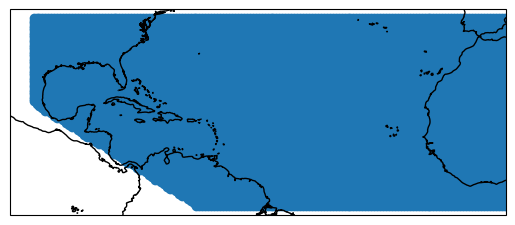

In [7]:
# plot basin
targetBasin = 'NA'

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

ax.scatter(basinmask_df['grid_xt'].loc[basinmask_df[targetBasin] == 1], basinmask_df['grid_yt'].loc[basinmask_df[targetBasin] == 1], transform=ccrs.PlateCarree())
ax.coastlines()

In [8]:
# function to get RI vs. non-RI distributions of dataset
def getRI_dist(GW, targetBasin, print_tracks):
    yearranges = [np.arange(year, year+10) for year in np.arange(1871, 2021, 10)]
    decades = [year for year in np.arange(1871, 2021, 10)]
    size = len(yearranges)
    pcts = np.zeros((2,size))

    # get basin boundary coordinates
    lon_min = basinmask_df[basinmask_df[targetBasin] == 1]['grid_xt'].min()
    lon_max = basinmask_df[basinmask_df[targetBasin] == 1]['grid_xt'].max()
    lat_min = basinmask_df[basinmask_df[targetBasin] == 1]['grid_yt'].min()
    lat_max = basinmask_df[basinmask_df[targetBasin] == 1]['grid_yt'].max()
    
    for index, yearrange in enumerate(yearranges):
        track_df = track_TCs.get_trackdf(GW, yearrange[0])
    
        # filter basin
        track_df = track_df[(track_df['center_lon'] >= lon_min) & (track_df['center_lon'] <= lon_max)] # filter by longitude
        track_df = track_df[(track_df['center_lat'] >= lat_min) & (track_df['center_lat'] <= lat_max)] # filter by latitude
        
        # plot track_df coordinates
        if print_tracks == 1:
            fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
            ax.scatter(track_df['center_lon'], track_df['center_lat'], transform=ccrs.PlateCarree())
            ax.coastlines()
    
        # get LMI of RI/nonRI storms
        lmi_ri_df, lmi_nonri_df = get_LMI_dfs(track_df)
    
        pLMI = len(lmi_ri_df) / (len(lmi_ri_df) + len(lmi_nonri_df))
        #print(f"% storms that are LMI {pLMI}")
        pcts[0,index] = pLMI
        pcts[1,index] = 1-pLMI

    return decades, pcts

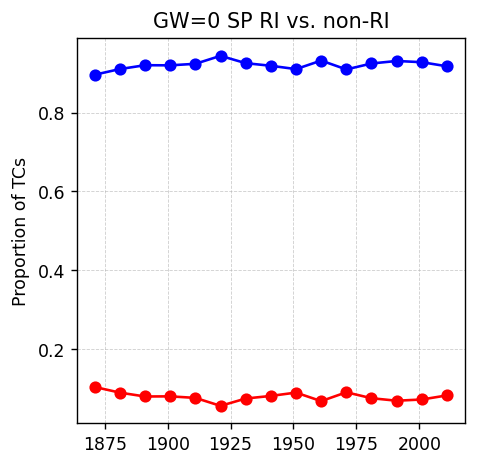

In [40]:
# RI vs. non-RI proportions per decade
# get data
GW = 0
targetBasin = 'SP'
print_tracks = 0

decades, pcts = getRI_dist(GW, targetBasin, print_tracks)

# plot data
fig, ax = plt.subplots(figsize=(4,4), dpi=125)
ax.plot(decades, pcts[0], marker='o', color='red', label=f"RI")
ax.plot(decades, pcts[1], marker='o', color='b', label=f"non-RI")

ax.set_title(f"GW={GW} {targetBasin} RI vs. non-RI")
ax.set_ylabel(f"Proportion of TCs")
#ax.legend()
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

In [9]:
# likelihood of storm being RI under GW=0 vs. GW=1
def plot_RI_LLH(targetBasin, print_tracks, fig, ax):
#def plot_RI_LLH(targetBasin, print_tracks):
    # get data
    decades, pcts_GW0 = getRI_dist(0, targetBasin, print_tracks)
    decades, pcts_GW1 = getRI_dist(1, targetBasin, print_tracks)
    
    ratio = pcts_GW1[0]/pcts_GW0[0] # ratio of RI likelihood under warming vs. rmWarming
    log_ratio = np.log10(ratio)
    
    # plot data
    #fig, ax = plt.subplots(figsize=(4,4), dpi=125)
    #ax.axhline(y=0, color='black')
    ax.plot(decades, log_ratio, marker='o', label=targetBasin, alpha=0.8)
    
    ax.set_title(f"{targetBasin} log(% RI in GW/NW)")
    #ax.set_ylim([-0.25, 0.25])
    #ax.legend()
    ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

targetBasin = 'EP'
print_tracks = 0
#plot_RI_LLH(targetBasin, print_tracks)

(-0.25, 0.3)

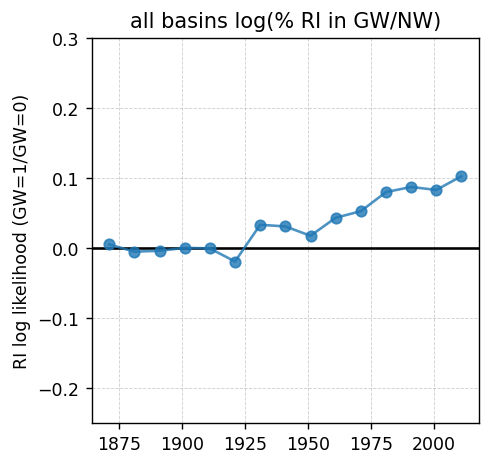

In [12]:
#basins = ['NA', 'EP', 'WP', 'SP']
basins = ['global']

fig, ax = plt.subplots(figsize=(4,4), dpi=125)
ax.axhline(y=0, color='black')

for targetBasin in basins:
    plot_RI_LLH(targetBasin, print_tracks, fig, ax)
#ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0)) # Places legend outside to the right

ax.set_title(f"all basins log(% RI in GW/NW)")
ax.set_ylabel(f"RI log likelihood (GW=1/GW=0)")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.set_ylim([-0.25, 0.3])

### TC count

In [43]:
# find average TS and TC count per year across 10 ensemble members

GW = 0

yearranges = [year for year in np.arange(1871, 2021, 10)] #15 total plots

# store storm counts in np arrays
numTS = np.zeros(len(yearranges))
numTC = np.zeros(len(yearranges))

i = 0

for year in yearranges:
    print(f"year: {year}")
    if GW == 1:
        picklename = f"trackdf_GW_{year}{year+10}.pkl"
        factor = 100 #GW has 10 ensemble members
    elif GW == 0:
        picklename = f"trackdf_NW_{year}{year+10}.pkl"
        factor = 50 #NW has 5 ensemble members
    
    track_df = pd.read_pickle(picklename)

    # TS
    TS_df = track_df[track_df['max_wind'] >= 17]
    numTS[i] = len(TS_df['storm_id'].unique()) / factor

    TC_df = track_df[track_df['max_wind'] >= 33]
    numTC[i] = len(TC_df['storm_id'].unique()) / factor
    
    i += 1

year: 1871
year: 1881
year: 1891
year: 1901
year: 1911
year: 1921
year: 1931
year: 1941
year: 1951
year: 1961
year: 1971
year: 1981
year: 1991
year: 2001
year: 2011


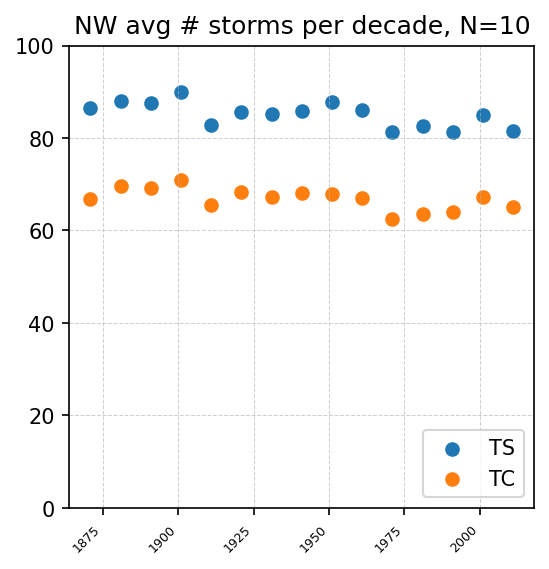

In [45]:
# plot TS and TC count
fig, ax = plt.subplots(figsize=(4,4), dpi=150)
ax.scatter(yearranges, numTS, label='TS')
ax.scatter(yearranges, numTC, label='TC')

ax.legend(loc='lower right') # Places legend outside to the right
ax.set_ylim([0, 100])
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)

if GW == 1:
    ax.set_title(f"GW avg # storms per decade, N=10")
elif GW == 0:
    ax.set_title(f"NW avg # storms per decade, N=10")

### stat boxplots

#### medians

In [ ]:
# extract statistic from each decade
importlib.reload(ap)

def get_medians(GW):
    if GW == 1:
        initialpath = "WARMING_MODEL_PATH"
        fenum = 1
    elif GW == 0:
        initialpath = "NONWARMING_MODEL_PATH"
        fenum = 6
    
    ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(fenum,11)]
    yearranges = [np.arange(year, year+10) for year in np.arange(1871, 2021, 10)] #15 total plots
    
    d_meds = []
    d_medsr = []
    d_stds = []
    d_stdsr = []
    
    for ennum in ennums:
        # collect data for each year
        temps = np.zeros((4,len(yearranges)))
        for index, yearrange in enumerate(yearranges):
            print(f"{yearrange}")
            print(f"{ennum}")
            track_df = pd.read_pickle(initialpath)
            
            lmi_ri_df, lmi_nonri_df = get_LMI_dfs(track_df)
            
            # store medians & std for ri and non-ri
            temps[0, index] = np.median(lmi_nonri_df['max_wind'])
            temps[1, index] = np.median(lmi_ri_df['max_wind'])
            temps[2, index] = np.std(lmi_nonri_df['max_wind'])
            temps[3, index] = np.std(lmi_ri_df['max_wind'])
            print(f"non-RI median: {np.median(lmi_nonri_df['max_wind'])}\n RI median: {np.median(lmi_ri_df['max_wind'])}")
            print(f"non-RI std: {np.std(lmi_nonri_df['max_wind'])}\n RI median: {np.std(lmi_ri_df['max_wind'])}")
            
        d_meds.extend(temps[0])
        d_medsr.extend(temps[1])
        d_stds.extend(temps[2])
        d_stdsr.extend(temps[3])
    
        '''
        # write into the file (inside for loop in case something fails)
        with open(file_name, "w") as f:
            f.write(str(d_meds) + "\n")
            f.write(str(d_medsr) + "\n")
            f.write(str(d_stds) + "\n")
            f.write(str(d_stdsr) + "\n")
        '''
    return d_meds, d_medsr, d_stds, d_stdsr

In [31]:
import pandas as pd

def create_medstat_df(GW, d_meds, d_medsr, d_stds, d_stdsr):
    decades = ['1870','1880','1890','1900','1910','1920','1930','1940','1950','1960','1970','1980','1990','2000','2010']
    
    if GW == 1:
        fenum = 1
    
    elif GW == 0:
        fenum = 6
    
    ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(fenum,11)]
    num_ens = len(ennums)
    data = {
            'decade': [x for i in range(2*num_ens) for x in decades],
            'en': [x for i in range(2) for x in ennums for j in range(15)],
            'dist': [f"nonri" if i < len(decades)*num_ens else f"ri" for i in range(len(decades)*num_ens*2)],
            'median': d_meds + d_medsr,
            'std': d_stds + d_stdsr
            }
    
    stats_df = pd.DataFrame(data)
    
    return stats_df

In [108]:
# sidebar (i)
# subtract GW - NW data
d_meds, d_medsr, d_stds, d_stdsr = get_medians(GW=1)
stats_dfGW = create_medstat_df(1, d_meds, d_medsr, d_stds, d_stdsr)

d_meds, d_medsr, d_stds, d_stdsr = get_medians(GW=0)
stats_dfNW = create_medstat_df(0, d_meds, d_medsr, d_stds, d_stdsr)

[1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]
01
non-RI median: 37.82
 RI median: 58.6
non-RI std: 8.977477571912827
 RI median: 10.032097042098881
[1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]
01
non-RI median: 37.69
 RI median: 59.05
non-RI std: 9.011674950205201
 RI median: 10.607259898126395
[1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]
01
non-RI median: 38.230000000000004
 RI median: 57.925
non-RI std: 9.429539466136903
 RI median: 10.307713734203725
[1901 1902 1903 1904 1905 1906 1907 1908 1909 1910]
01
non-RI median: 37.245
 RI median: 57.34
non-RI std: 8.718130991721969
 RI median: 10.86269794753485
[1911 1912 1913 1914 1915 1916 1917 1918 1919 1920]
01
non-RI median: 38.07
 RI median: 58.365
non-RI std: 9.1872423592221
 RI median: 10.781385254865949
[1921 1922 1923 1924 1925 1926 1927 1928 1929 1930]
01
non-RI median: 37.83
 RI median: 59.11
non-RI std: 9.347260786598428
 RI median: 10.248384459353376
[1931 1932 1933 1934 1935 1936 1937 1938 1939 1940]
01
non

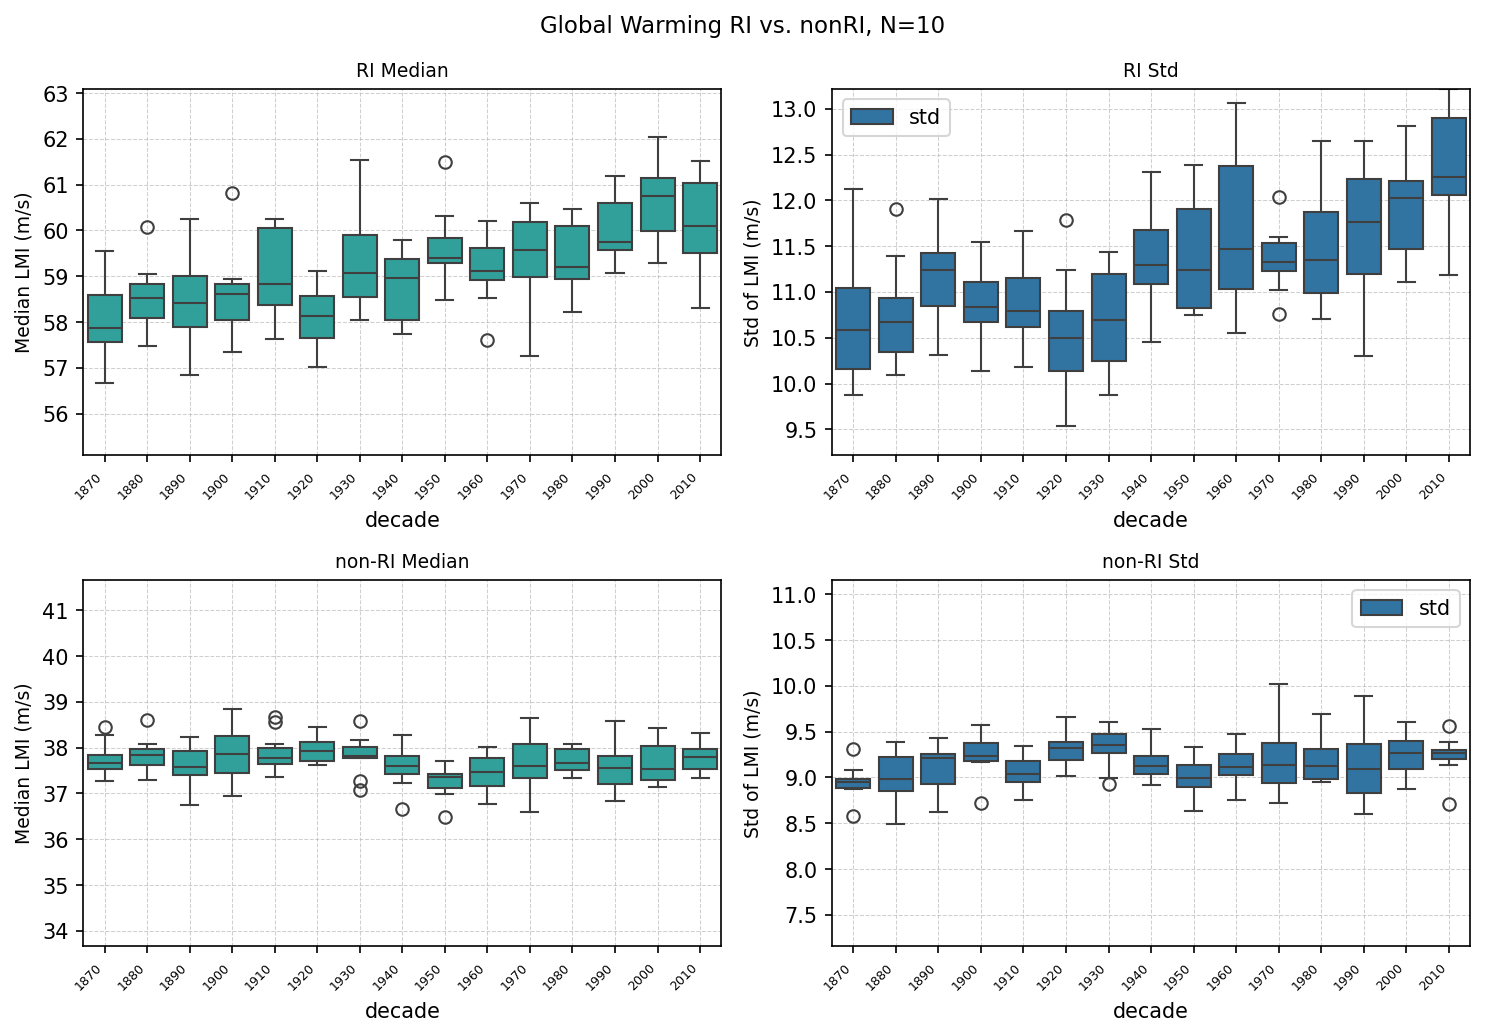

In [40]:
# plot boxplot

import matplotlib, matplotlib.pyplot as plt
import seaborn as sns

# set window sizes
mwindow = 4
swindow = 2

#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html

order = ['1870','1880','1890','1900','1910','1920','1930','1940','1950','1960','1970','1980','1990','2000','2010']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,7), dpi=150)

sns.boxplot(x='decade', y='median', data=stats_df[stats_df['dist']=='ri'], ax=axs[0,0], color='lightseagreen', label='median', order=order, legend=False)
sns.boxplot(x='decade', y='median', data=stats_df[stats_df['dist']=='nonri'], ax=axs[1,0], color='lightseagreen', label='median', order=order, legend=False)
sns.boxplot(x='decade', y='std', data=stats_df[stats_df['dist']=='ri'], ax=axs[0,1], label='std', order=order)
sns.boxplot(x='decade', y='std', data=stats_df[stats_df['dist']=='nonri'], ax=axs[1,1], label='std', order=order)

# set equal window sizes
mr_mid = np.median(stats_df[stats_df['dist']=='ri']['median'])
m_mid = np.median(stats_df[stats_df['dist']=='nonri']['median'])
sr_mid = np.median(stats_df[stats_df['dist']=='ri']['std'])
s_mid = np.median(stats_df[stats_df['dist']=='nonri']['std'])

axs[0,0].set_ylim([mr_mid-mwindow, mr_mid+mwindow])
axs[1,0].set_ylim([m_mid-mwindow, m_mid+mwindow])
axs[0,1].set_ylim([sr_mid-swindow, sr_mid+swindow])
axs[1,1].set_ylim([s_mid-swindow, s_mid+swindow])
# ----------

axs[0,0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[1,0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[0,1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[1,1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[0,1].set_xticklabels(axs[0,1].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[1,1].set_xticklabels(axs[1,1].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[0,0].set_xticklabels(axs[0,0].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[1,0].set_xticklabels(axs[1,0].get_xticklabels(), rotation=45, ha='right', fontsize=6)

axs[0,0].set_ylabel(f"Median LMI (m/s)", fontsize=9)
axs[1,0].set_ylabel(f"Median LMI (m/s)", fontsize=9)
axs[0,1].set_ylabel(f"Std of LMI (m/s)", fontsize=9)
axs[1,1].set_ylabel(f"Std of LMI (m/s)", fontsize=9)
axs[0,0].set_title(f"RI Median", fontsize=9)
axs[1,0].set_title(f"non-RI Median", fontsize=9)
axs[0,1].set_title(f"RI Std", fontsize=9)
axs[1,1].set_title(f"non-RI Std", fontsize=9)

if GW == 1:
    fig.suptitle(f"Global Warming RI vs. nonRI, N=10", fontsize=11)
elif GW == 0:
    fig.suptitle(f"No Warming RI vs. nonRI, N=5", fontsize=11, legend=False)
plt.tight_layout()

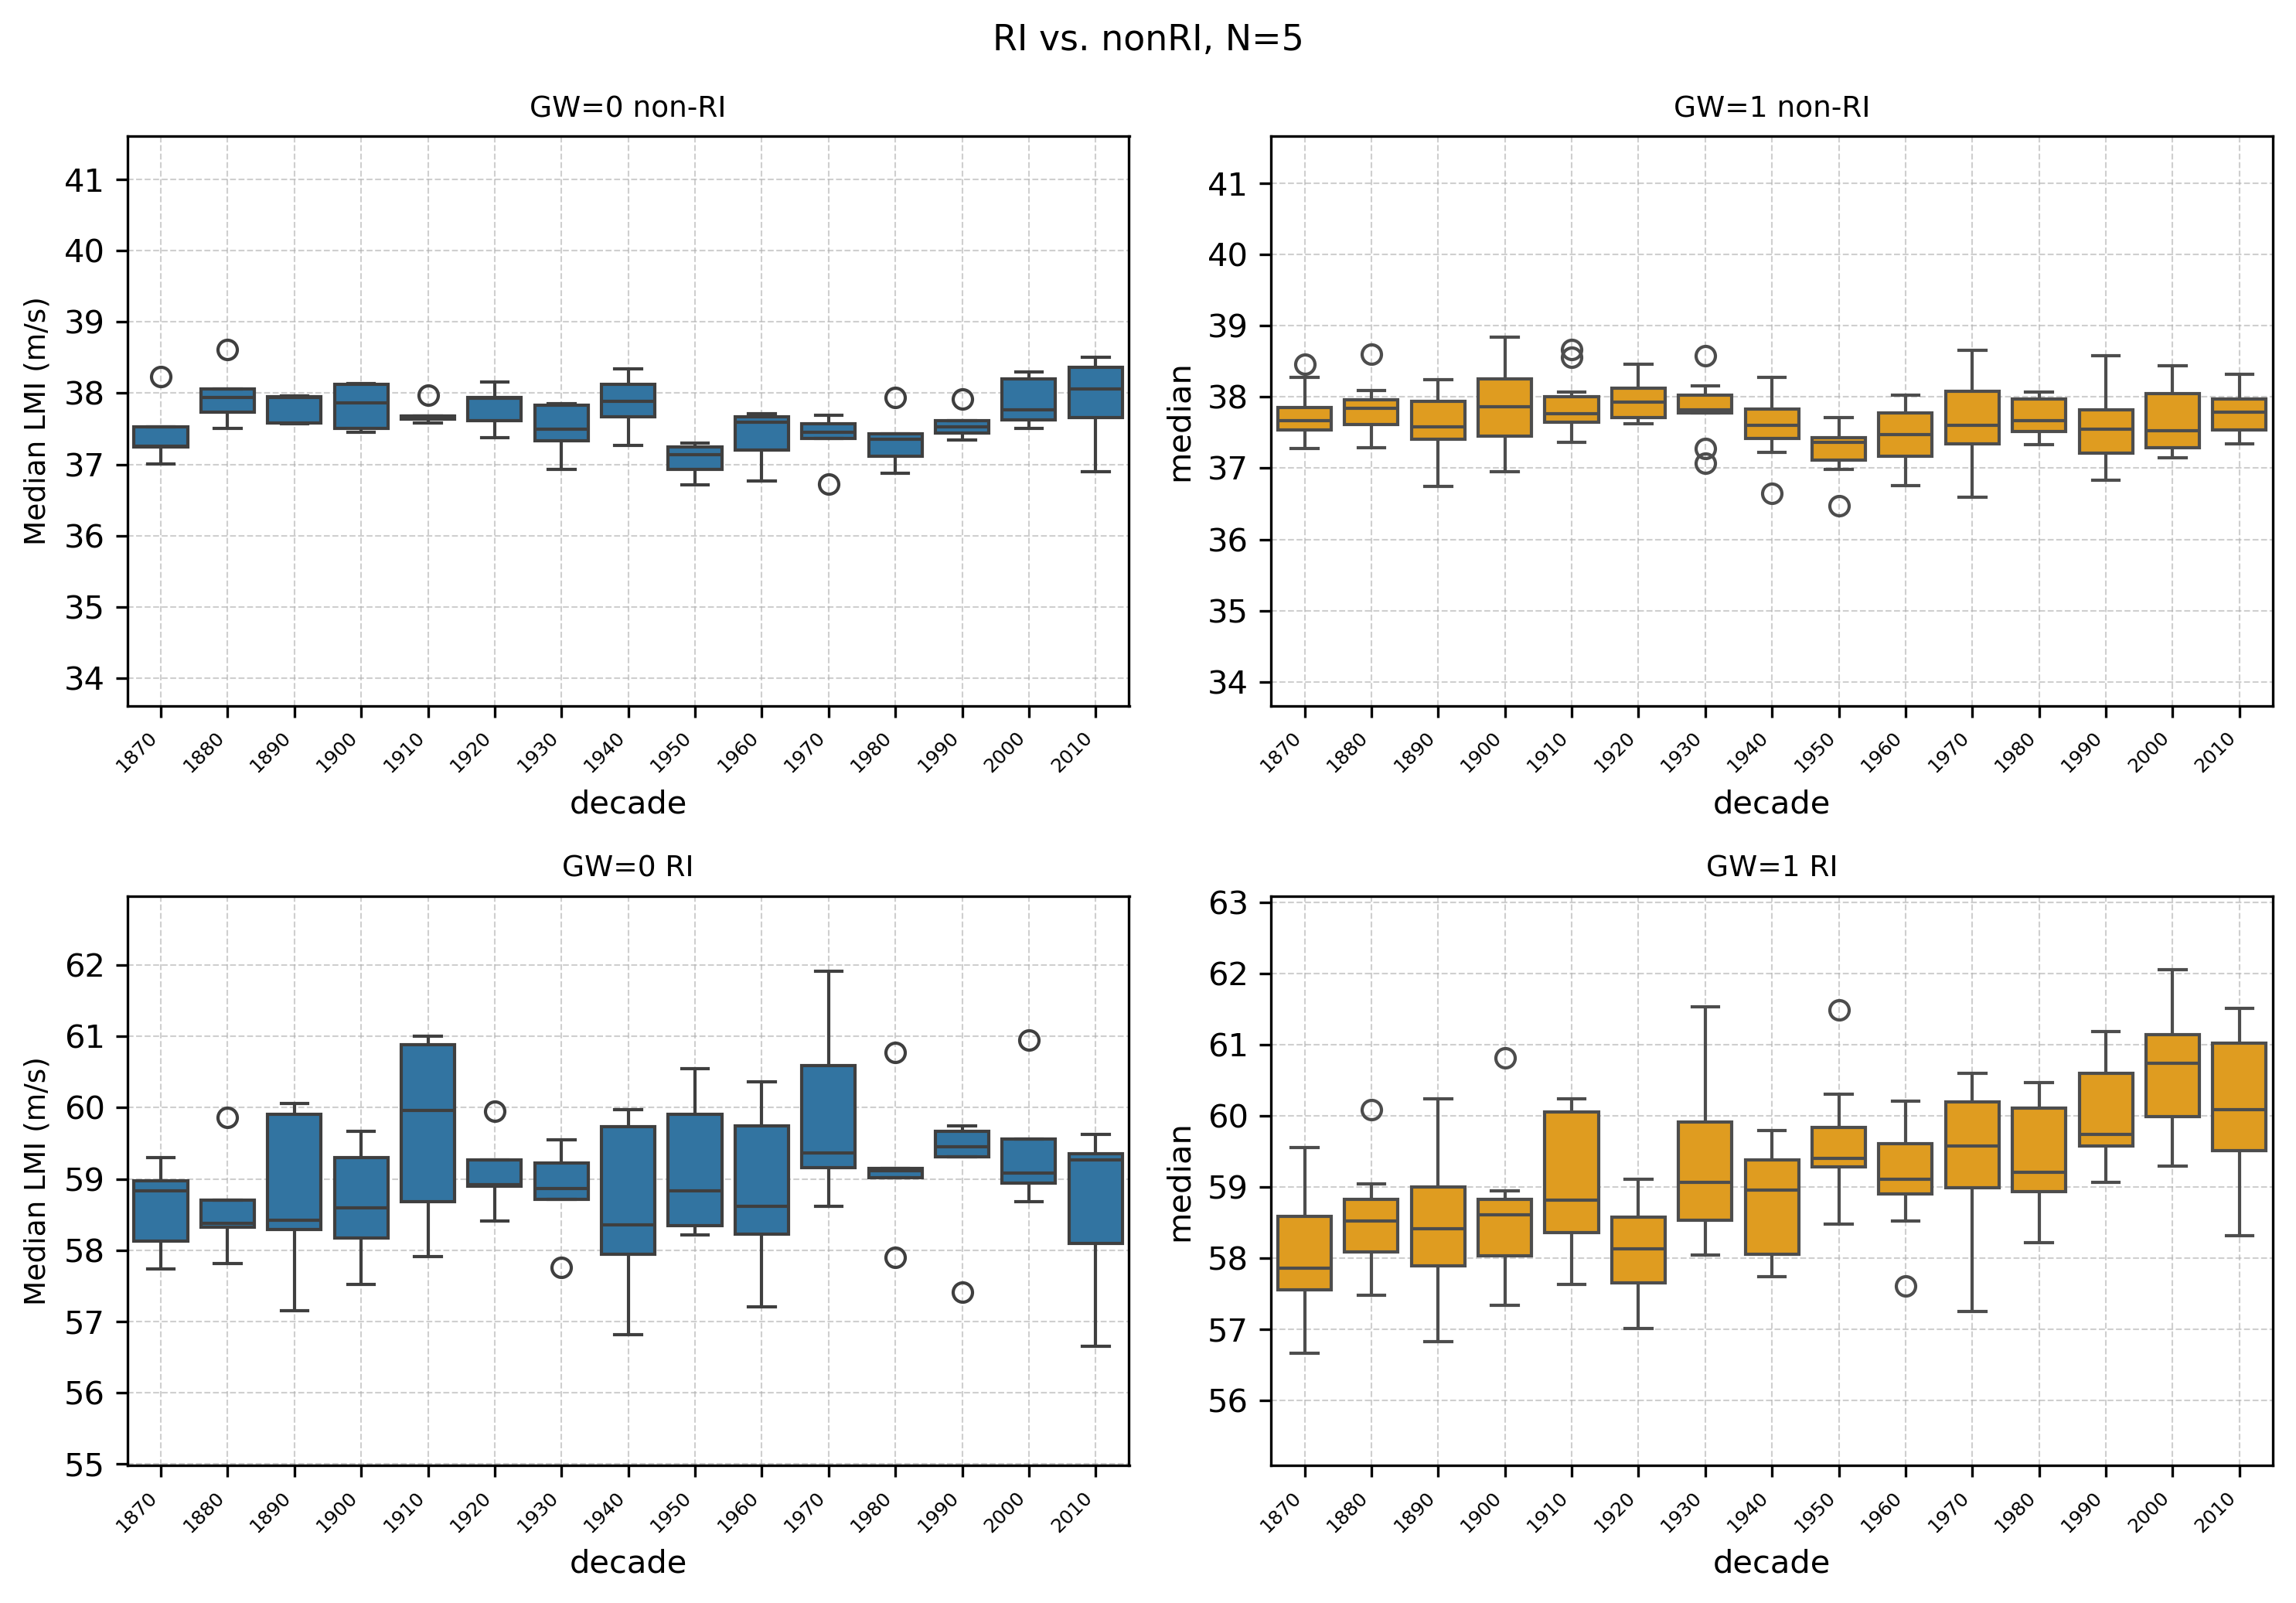

In [109]:
# plot GW=0 vs. GW=1 boxplots

import matplotlib, matplotlib.pyplot as plt
import seaborn as sns

# set window sizes
mwindow = 4
swindow = 4

#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html

order = ['1870','1880','1890','1900','1910','1920','1930','1940','1950','1960','1970','1980','1990','2000','2010']

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,7), dpi=300)

sns.boxplot(x='decade', y='median', data=stats_dfNW[stats_dfNW['dist']=='nonri'], ax=axs[0,0], label='NW nonRI', order=order, legend=False)
sns.boxplot(x='decade', y='median', data=stats_dfNW[stats_dfNW['dist']=='ri'], ax=axs[1,0], label='NW RI', order=order, legend=False)
sns.boxplot(x='decade', y='median', data=stats_dfGW[stats_dfGW['dist']=='nonri'], ax=axs[0,1], color='orange', label='GW nonRI', order=order, legend=False)
sns.boxplot(x='decade', y='median', data=stats_dfGW[stats_dfGW['dist']=='ri'], ax=axs[1,1], color='orange', label='GW RI', order=order, legend=False)

# set equal window sizes
mr_mid = np.median(stats_dfNW[stats_dfNW['dist']=='ri']['median'])
m_mid = np.median(stats_dfNW[stats_dfNW['dist']=='nonri']['median'])
sr_mid = np.median(stats_dfGW[stats_dfGW['dist']=='ri']['median'])
s_mid = np.median(stats_dfGW[stats_dfGW['dist']=='nonri']['median'])

axs[0,0].set_ylim([m_mid-mwindow, m_mid+mwindow])
axs[1,0].set_ylim([mr_mid-mwindow, mr_mid+mwindow])
axs[0,1].set_ylim([s_mid-swindow, s_mid+swindow])
axs[1,1].set_ylim([sr_mid-swindow, sr_mid+swindow])
# ----------

axs[0,0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[1,0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[0,1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[1,1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[0,1].set_xticklabels(axs[0,1].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[1,1].set_xticklabels(axs[1,1].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[0,0].set_xticklabels(axs[0,0].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[1,0].set_xticklabels(axs[1,0].get_xticklabels(), rotation=45, ha='right', fontsize=6)

axs[0,0].set_ylabel(f"Median LMI (m/s)", fontsize=9)
axs[1,0].set_ylabel(f"Median LMI (m/s)", fontsize=9)
axs[0,0].set_title(f"GW=0 non-RI", fontsize=9)
axs[1,0].set_title(f"GW=0 RI", fontsize=9)
axs[0,1].set_title(f"GW=1 non-RI", fontsize=9)
axs[1,1].set_title(f"GW=1 RI", fontsize=9)

fig.suptitle(f"RI vs. nonRI, N=5", fontsize=11)
plt.tight_layout()

##### save stats file

In [ ]:
# compile stat data lists from txt files (if necessary)
import ast

GW = 0

if GW == 1:
    file1 = f"GW_en01-06stats.txt"
    file2 = f"GW_en07-10stats.txt"
    
    # Parse txt files: adapted from ChatGPT
    Lfile1 = []
    Lfile2 = []
    
    for i in range(2):
        if i == 0:
            filename = file1
        else:
            filename = file2
        
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line:                     # skip empty lines
                    if i == 0:
                        Lfile1.append(ast.literal_eval(line))
                    else:
                        Lfile2.append(ast.literal_eval(line))
    
    # shape to make compatible for dataframe
    d_meds = Lfile1[0] + Lfile2[0] + Lfile1[1] + Lfile2[1]
    d_stds = Lfile1[2] + Lfile2[2] + Lfile1[3] + Lfile2[3]

elif GW == 0:
    file_name = f"NW_en06-11stats.txt"
    Lfile1 = []
    
    with open(file_name, "r") as f:
        for line in f:
            line = line.strip()
            if line:                     # skip empty lines
                Lfile1.append(ast.literal_eval(line))
                
    d_meds = Lfile1[0] + Lfile1[1]
    d_stds = Lfile1[2] + Lfile1[3]

#### percentiles

In [ ]:
# extract statistic from each decade
importlib.reload(ap)

def get_percentiles(GW, percentiles):
    if GW == 1:
        fenum = 1
        fix = "GW"

        rand_ens = np.random.choice(range(1,11), 5, False)
        ennums = [f"0{i}" if i < 10 else f"{i}" for i in rand_ens]
    elif GW == 0:
        fenum = 6
        fix = "NW"
    
        ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(fenum,11)]

    yearranges = [np.arange(year, year+10) for year in np.arange(1871, 2021, 10)] #15 total plots
    
    d_stats_n = [[] for i in range(len(percentiles))] # stores percentiles for non-RI storms in each decade in each enum
    d_stats_r = [[] for i in range(len(percentiles))] # stores percentiles for RI storms in each decade in each enum
    
    for ennum in ennums:
        # collect data for each year
        temps = []
        for index, yearrange in enumerate(yearranges):
            print(f"{yearrange}")
            print(f"{ennum}")
            track_df = pd.read_pickle("TRACK_PATH")
            
            lmi_ri_df, lmi_nonri_df = get_LMI_dfs(track_df)
            
            # store medians & std for ri and non-ri
            pcts_n = np.percentile(lmi_nonri_df['max_wind'], percentiles)
            pcts_r = np.percentile(lmi_ri_df['max_wind'], percentiles)
            #print(f"pcts_n: {pcts_n}\n pcts_ri: {pcts_r}")
    
            for i in range(len(percentiles)):
                d_stats_n[i].append(pcts_n[i])
                d_stats_r[i].append(pcts_r[i])
    
    # length of each percentile list should be 75
        # 5 ensembles x 15 decades
    return d_stats_n, d_stats_r, ennums

In [74]:
import pandas as pd

def create_pstat_df(GW, percentiles, d_stats_n, d_stats_r):
    decades = ['1870','1880','1890','1900','1910','1920','1930','1940','1950','1960','1970','1980','1990','2000','2010']
    
    if GW == 1:
        fenum = 1
    
    elif GW == 0:
        fenum = 6
    
    ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(fenum,11)]
    num_ens = len(ennums)
    data = {
            'decade': [x for i in range(2*num_ens) for x in decades],
            'en': [x for i in range(2) for x in ennums for j in range(len(decades))],
            'dist': [f"nonri" if i < len(decades)*num_ens else f"ri" for i in range(len(decades)*num_ens*2)]
            }
    
    i = 0
    for pct in percentiles:
        data[f"{pct}th"] = d_stats_n[i] + d_stats_r[i]
        i += 1
    
    stats_df = pd.DataFrame(data)
    return stats_df

In [ ]:
# sidebar (i)
# subtract GW - NW data
desired_percents = [5, 25, 75, 90, 95] # set with desired percentiles up to 4

# pick 5 random ensemble members for GW
d_stats_n, d_stats_r, ennums = get_percentiles(GW=1, percentiles=desired_percents)
decades = ['1870','1880','1890','1900','1910','1920','1930','1940','1950','1960','1970','1980','1990','2000','2010']

num_ens = len(ennums)
data = {
        'decade': [x for i in range(2*num_ens) for x in decades],
        'en': [x for i in range(2) for x in ennums for j in range(len(decades))],
        'dist': [f"nonri" if i < len(decades)*num_ens else f"ri" for i in range(len(decades)*num_ens*2)]
        }

i = 0
for pct in desired_percents:
    data[f"{pct}th"] = d_stats_n[i] + d_stats_r[i]
    i += 1

stats_dfGW = pd.DataFrame(data)


# NW data
d_stats_n, d_stats_r, ennums = get_percentiles(GW=0, percentiles=desired_percents)
stats_dfNW = create_pstat_df(0, desired_percents, d_stats_n, d_stats_r)

[1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]
02
[1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]
02
[1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]
02
[1901 1902 1903 1904 1905 1906 1907 1908 1909 1910]
02
[1911 1912 1913 1914 1915 1916 1917 1918 1919 1920]
02
[1921 1922 1923 1924 1925 1926 1927 1928 1929 1930]
02
[1931 1932 1933 1934 1935 1936 1937 1938 1939 1940]
02
[1941 1942 1943 1944 1945 1946 1947 1948 1949 1950]
02
[1951 1952 1953 1954 1955 1956 1957 1958 1959 1960]
02
[1961 1962 1963 1964 1965 1966 1967 1968 1969 1970]
02
[1971 1972 1973 1974 1975 1976 1977 1978 1979 1980]
02
[1981 1982 1983 1984 1985 1986 1987 1988 1989 1990]
02
[1991 1992 1993 1994 1995 1996 1997 1998 1999 2000]
02
[2001 2002 2003 2004 2005 2006 2007 2008 2009 2010]
02
[2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]
02
[1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]
04
[1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]
04
[1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]
04
[1901 1902

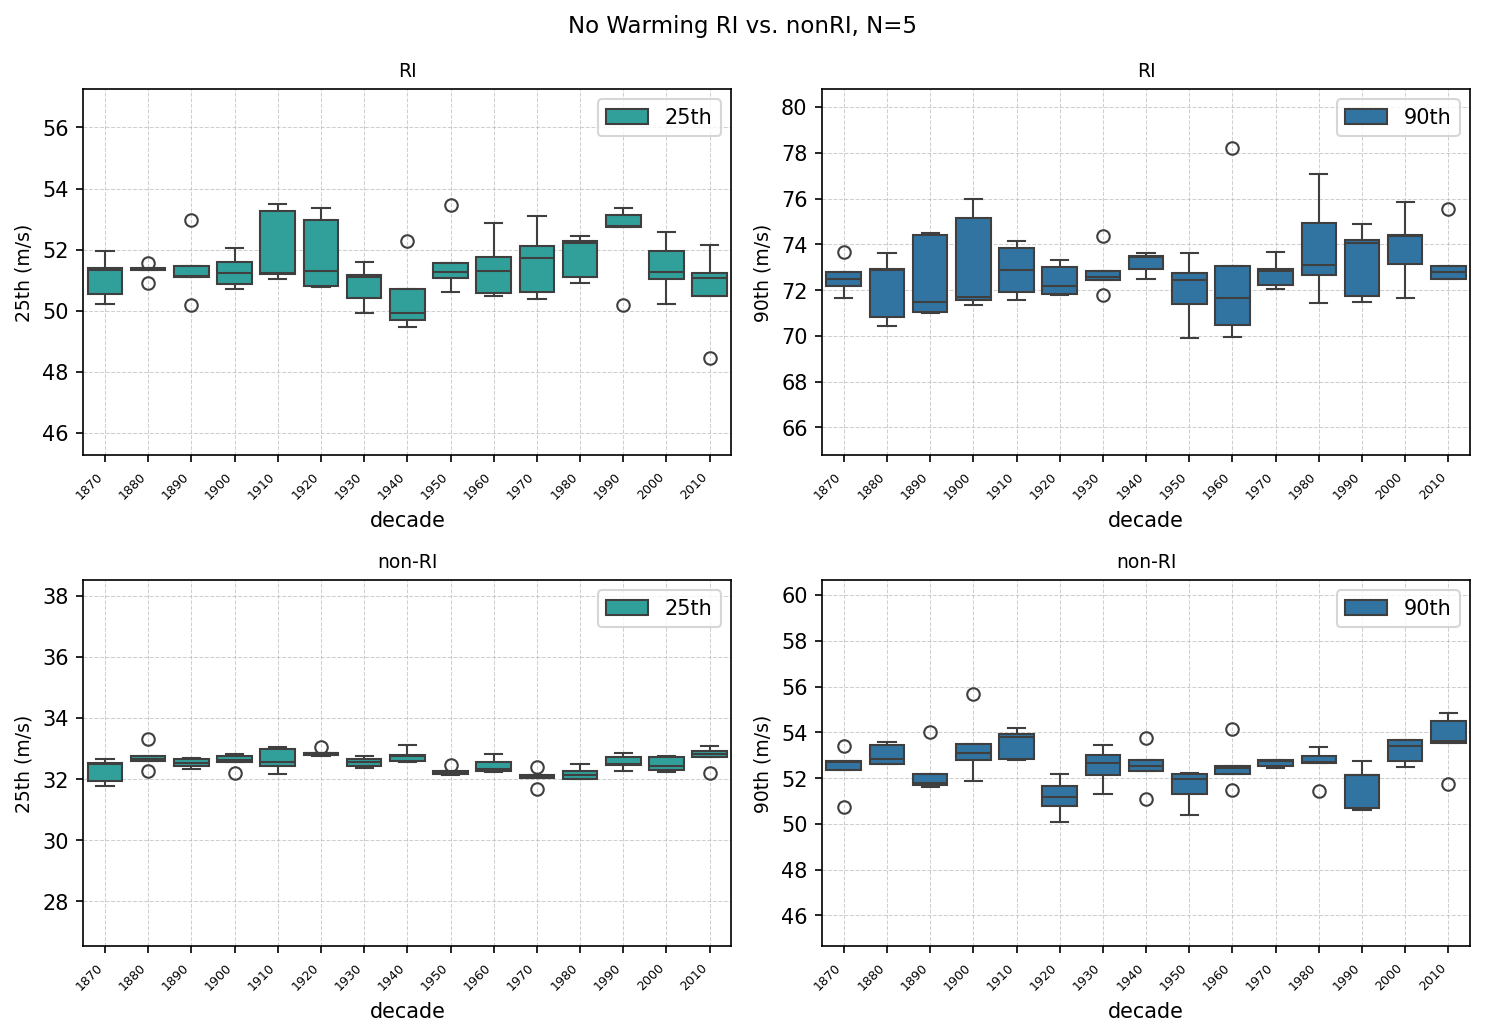

In [81]:
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns

#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html

GW = 0
stats_df = stats_dfNW
target_vars = ("25th", "90th") # set desired parameters to plot

# set window sizes
mwindow = 6
swindow = 8

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,7), dpi=150)

sns.boxplot(x='decade', y=target_vars[0], data=stats_df[stats_df['dist']=='ri'], ax=axs[0,0], color='lightseagreen', label=target_vars[0])
sns.boxplot(x='decade', y=target_vars[0], data=stats_df[stats_df['dist']=='nonri'], ax=axs[1,0], color='lightseagreen', label=target_vars[0])
sns.boxplot(x='decade', y=target_vars[1], data=stats_df[stats_df['dist']=='ri'], ax=axs[0,1], label=target_vars[1])
sns.boxplot(x='decade', y=target_vars[1], data=stats_df[stats_df['dist']=='nonri'], ax=axs[1,1], label=target_vars[1])


# set equal window sizes
r1 = np.median(stats_df[stats_df['dist']=='ri'][target_vars[0]])
n1 = np.median(stats_df[stats_df['dist']=='nonri'][target_vars[0]])
r2 = np.median(stats_df[stats_df['dist']=='ri'][target_vars[1]])
n2 = np.median(stats_df[stats_df['dist']=='nonri'][target_vars[1]])

axs[0,0].set_ylim([r1-mwindow, r1+mwindow])
axs[1,0].set_ylim([n1-mwindow, n1+mwindow])
axs[0,1].set_ylim([r2-swindow, r2+swindow])
axs[1,1].set_ylim([n2-swindow, n2+swindow])

# ----------

axs[0,0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[1,0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[0,1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[1,1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[0,1].set_xticklabels(axs[0,1].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[1,1].set_xticklabels(axs[1,1].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[0,0].set_xticklabels(axs[0,0].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[1,0].set_xticklabels(axs[1,0].get_xticklabels(), rotation=45, ha='right', fontsize=6)


axs[0,0].set_ylabel(f"{target_vars[0]} (m/s)", fontsize=9)
axs[1,0].set_ylabel(f"{target_vars[0]} (m/s)", fontsize=9)
axs[0,1].set_ylabel(f"{target_vars[1]} (m/s)", fontsize=9)
axs[1,1].set_ylabel(f"{target_vars[1]} (m/s)", fontsize=9)

axs[0,0].set_title(f"RI", fontsize=9)
axs[0,1].set_title(f"RI", fontsize=9)
axs[1,0].set_title(f"non-RI", fontsize=9)
axs[1,1].set_title(f"non-RI", fontsize=9)

if GW == 1:
    fig.suptitle(f"Global Warming RI vs. nonRI, N=5", fontsize=11)
elif GW == 0:
    fig.suptitle(f"No Warming RI vs. nonRI, N=5", fontsize=11)

plt.tight_layout()

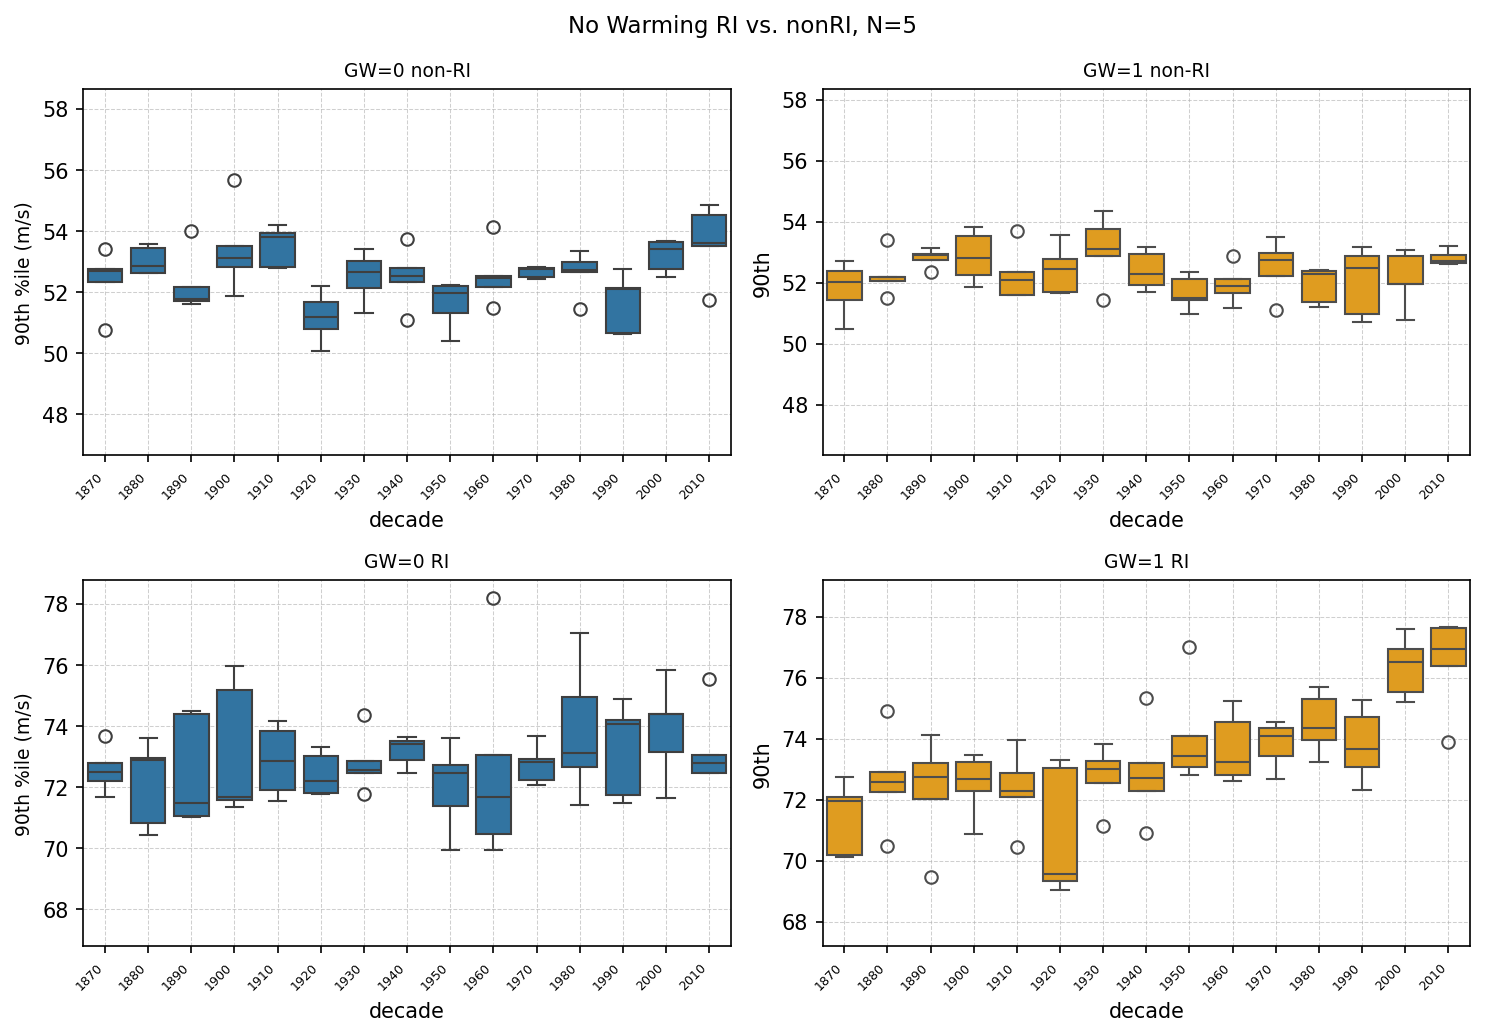

In [107]:
# plot GW=0 vs. GW=1 boxplots

#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html

target_var = "90th" # set desired parameters to plot

# set window sizes
window = 6

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,7), dpi=150)

sns.boxplot(x='decade', y=target_var, data=stats_dfNW[stats_dfNW['dist']=='nonri'], ax=axs[0,0], label="GW=0 nonRI", legend=False)
sns.boxplot(x='decade', y=target_var, data=stats_dfNW[stats_dfNW['dist']=='ri'], ax=axs[1,0], label="GW=0 RI", legend=False)
sns.boxplot(x='decade', y=target_var, data=stats_dfGW[stats_dfGW['dist']=='nonri'], ax=axs[0,1], color='orange', label="GW=1 nonRI", legend=False)
sns.boxplot(x='decade', y=target_var, data=stats_dfGW[stats_dfGW['dist']=='ri'], ax=axs[1,1], color='orange', label="GW=1 RI", legend=False)


# set equal window sizes
r1 = np.median(stats_dfNW[stats_dfNW['dist']=='ri'][target_var])
n1 = np.median(stats_dfNW[stats_dfNW['dist']=='nonri'][target_var])
r2 = np.median(stats_dfGW[stats_dfGW['dist']=='ri'][target_var])
n2 = np.median(stats_dfGW[stats_dfGW['dist']=='nonri'][target_var])


axs[0,0].set_ylim([n1-window, n1+window])
axs[0,1].set_ylim([n2-window, n2+window])
axs[1,0].set_ylim([r1-window, r1+window])
axs[1,1].set_ylim([r2-window, r2+window])

# ----------

axs[0,0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[1,0].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[0,1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[1,1].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
axs[0,1].set_xticklabels(axs[0,1].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[1,1].set_xticklabels(axs[1,1].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[0,0].set_xticklabels(axs[0,0].get_xticklabels(), rotation=45, ha='right', fontsize=6)
axs[1,0].set_xticklabels(axs[1,0].get_xticklabels(), rotation=45, ha='right', fontsize=6)


axs[0,0].set_ylabel(f"{target_var} %ile (m/s)", fontsize=9)
axs[1,0].set_ylabel(f"{target_var} %ile (m/s)", fontsize=9)

axs[0,0].set_title(f"GW=0 non-RI", fontsize=9)
axs[0,1].set_title(f"GW=1 non-RI", fontsize=9)
axs[1,0].set_title(f"GW=0 RI", fontsize=9)
axs[1,1].set_title(f"GW=1 RI", fontsize=9)

if GW == 1:
    fig.suptitle(f"Global Warming RI vs. nonRI, N=5", fontsize=11)
elif GW == 0:
    fig.suptitle(f"No Warming RI vs. nonRI, N=5", fontsize=11)

plt.tight_layout()

Text(0.5, 0.98, 'GW - NW Offset 90th %ile, N=5,5')

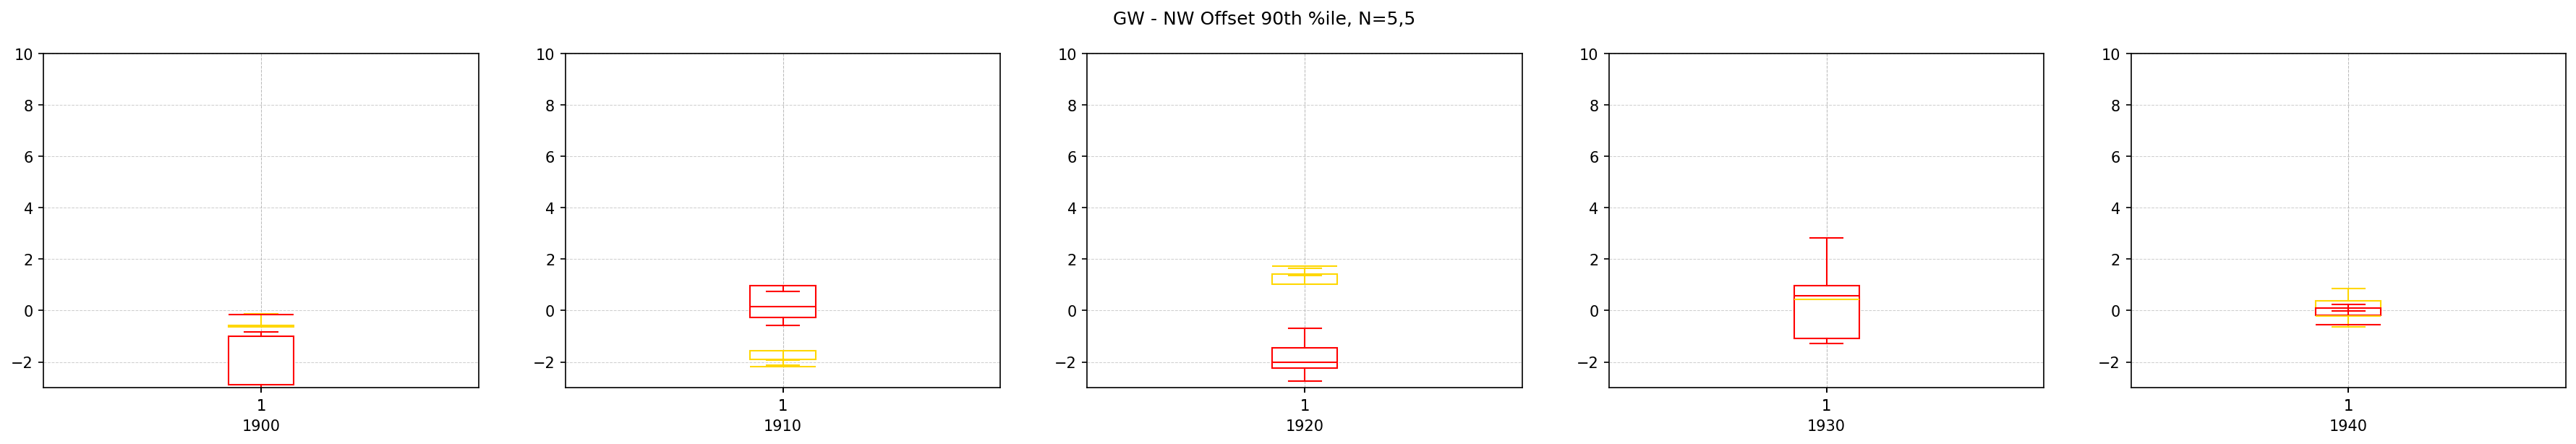

In [35]:
# sidebar (ii)
from matplotlib import cbook

pct_plot = 90

# plot offset boxplots subtract GW - NW data
fig, axs = plt.subplots(nrows=1, ncols=len(decades), figsize=(30, 4), dpi=150)

j = 0
for decade in decades:
    data_NW = stats_dfNW[(stats_dfNW['dist'] == 'nonri') & (stats_dfNW['decade'] == decade)]
    data_GW = stats_dfGW[(stats_dfGW['dist'] == 'nonri') & (stats_dfGW['decade'] == decade)]
    
    data_NWr = stats_dfNW[(stats_dfNW['dist'] == 'ri') & (stats_dfNW['decade'] == decade)]
    data_GWr = stats_dfGW[(stats_dfGW['dist'] == 'ri') & (stats_dfGW['decade'] == decade)]

    # boxplot_stats returns list containing dictionary
    med_NW_bxp = cbook.boxplot_stats(data_NW[f"{str(pct_plot)}th"])
    med_GW_bxp = cbook.boxplot_stats(data_GW[f"{str(pct_plot)}th"])
    
    medr_NW_bxp = cbook.boxplot_stats(data_NWr[f"{str(pct_plot)}th"])
    medr_GW_bxp = cbook.boxplot_stats(data_GWr[f"{str(pct_plot)}th"])

    # calculate difference GW - NW
    offsets = [med_GW_bxp[0][i] - med_NW_bxp[0][i] if i != "fliers" else "" for i in med_GW_bxp[0].keys()] # get rid of outliers
    offsetsr = [medr_GW_bxp[0][i] - medr_NW_bxp[0][i] if i != "fliers" else "" for i in medr_GW_bxp[0].keys()] # get rid of outliers

    # populate statistic dictionary
    offset_bxp = {}
    offsetsr_bxp = {}
    
    s = 0
    for k in med_GW_bxp[0].keys():
        offset_bxp[k] = offsets[s]
        offsetsr_bxp[k] = offsetsr[s]
        s += 1

    # PLOT
    box = axs[j].bxp([offset_bxp], patch_artist=True)
    boxr = axs[j].bxp([offsetsr_bxp], patch_artist=True)

    for item in ['whiskers', 'fliers', 'medians', 'caps']:
        plt.setp(box[item], color='gold')
        plt.setp(boxr[item], color='red')
    plt.setp(box["boxes"], facecolor='white', edgecolor='gold')
    plt.setp(boxr["boxes"], facecolor='white', edgecolor='red')

    ylims = [-3,10]
    axs[j].set_ylim(ylims)
    axs[j].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    axs[j].set_xlabel(f"{decade}")
    
    j += 1

fig.suptitle(f"GW - NW Offset {str(pct_plot)}th %ile, N=5,5")

20th cent split

In [90]:
# extract statistic from each decade
importlib.reload(ap)

#GW = 1
#percentiles = [5, 95] # set with desired percentiles up to 4

def get_percentiles(GW, percentiles):
    if GW == 1:
        fenum = 1
        fix = "GW"

        rand_ens = np.random.choice(range(1,11), 5, False)
        ennums = [f"0{i}" if i < 10 else f"{i}" for i in rand_ens]
    elif GW == 0:
        fenum = 6
        fix = "NW"
    
        ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(fenum,11)]

    yearranges = [np.arange(year, year+10) for year in np.arange(1951, 2001, 10)] #15 total plots
    
    d_stats_n = [[] for i in range(len(percentiles))] # stores percentiles for non-RI storms in each decade in each enum
    d_stats_r = [[] for i in range(len(percentiles))] # stores percentiles for RI storms in each decade in each enum
    
    for ennum in ennums:
        for index, yearrange in enumerate(yearranges):
            if index == 0 and ennum == ennums[0]:
                track_df = pd.read_pickle(f"trackdf_{fix}_en{ennum}_{yearrange[0]}{yearrange[-1]}.pkl")
            else:
                temp_df = pd.read_pickle(f"trackdf_{fix}_en{ennum}_{yearrange[0]}{yearrange[-1]}.pkl")
                track_df = pd.concat([track_df, temp_df])
    lmi_ri_df, lmi_nonri_df = get_LMI_dfs(track_df)
            
    # store medians & std for ri and non-ri
    pcts_n = np.percentile(lmi_nonri_df['max_wind'], percentiles)
    pcts_r = np.percentile(lmi_ri_df['max_wind'], percentiles)
    #print(f"pcts_n: {pcts_n}\n pcts_ri: {pcts_r}")

    for i in range(len(percentiles)):
        d_stats_n[i].append(pcts_n[i])
        d_stats_r[i].append(pcts_r[i])

    return d_stats_n, d_stats_r, ennums

In [91]:
import pandas as pd

def create_pstat_df(GW, percentiles, d_stats_n, d_stats_r):
    #decades = ['1870','1880','1890','1900','1910','1920','1930','1940','1950','1960','1970','1980','1990','2000','2010']
    decades = ['1950-2000']
    
    if GW == 1:
        fenum = 1
    
    elif GW == 0:
        fenum = 6
    
    #ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(fenum,11)]
    #num_ens = len(ennums)
    num_ens = 1
    data = {
            'decade': [x for i in range(2*num_ens) for x in decades],
            #'en': [x for i in range(2) for x in ennums for j in range(len(decades))],
            'dist': [f"nonri" if i < len(decades)*num_ens else f"ri" for i in range(len(decades)*num_ens*2)]
            }
    
    i = 0
    for pct in percentiles:
        data[f"{pct}th"] = d_stats_n[i] + d_stats_r[i]
        i += 1
    
    stats_df = pd.DataFrame(data)
    return stats_df

Text(0.5, 0.98, 'GW - NW Offset 90th %ile, N=5,5')

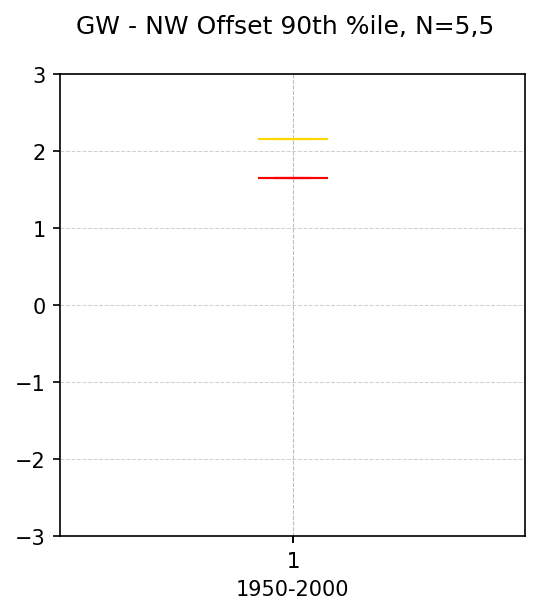

In [102]:
# sidebar (ii)
from matplotlib import cbook

pct_plot = 90

# plot offset boxplots subtract GW - NW data
fig, axs = plt.subplots(nrows=1, ncols=len(decades), figsize=(4,4), dpi=150)

j = 0
for decade in decades:
    data_NW = stats_dfNW[(stats_dfNW['dist'] == 'nonri') & (stats_dfNW['decade'] == decade)]
    data_GW = stats_dfGW[(stats_dfGW['dist'] == 'nonri') & (stats_dfGW['decade'] == decade)]
    
    data_NWr = stats_dfNW[(stats_dfNW['dist'] == 'ri') & (stats_dfNW['decade'] == decade)]
    data_GWr = stats_dfGW[(stats_dfGW['dist'] == 'ri') & (stats_dfGW['decade'] == decade)]

    # boxplot_stats returns list containing dictionary
    med_NW_bxp = cbook.boxplot_stats(data_NW[f"{str(pct_plot)}th"])
    med_GW_bxp = cbook.boxplot_stats(data_GW[f"{str(pct_plot)}th"])
    
    medr_NW_bxp = cbook.boxplot_stats(data_NWr[f"{str(pct_plot)}th"])
    medr_GW_bxp = cbook.boxplot_stats(data_GWr[f"{str(pct_plot)}th"])

    # calculate difference GW - NW
    offsets = [med_GW_bxp[0][i] - med_NW_bxp[0][i] if i != "fliers" else "" for i in med_GW_bxp[0].keys()] # get rid of outliers
    offsetsr = [medr_GW_bxp[0][i] - medr_NW_bxp[0][i] if i != "fliers" else "" for i in medr_GW_bxp[0].keys()] # get rid of outliers

    # populate statistic dictionary
    offset_bxp = {}
    offsetsr_bxp = {}
    
    s = 0
    for k in med_GW_bxp[0].keys():
        offset_bxp[k] = offsets[s]
        offsetsr_bxp[k] = offsetsr[s]
        s += 1

    # PLOT
    #box = axs[j].bxp([offset_bxp], patch_artist=True)
    #boxr = axs[j].bxp([offsetsr_bxp], patch_artist=True)
    box = axs.bxp([offset_bxp], patch_artist=True)
    boxr = axs.bxp([offsetsr_bxp], patch_artist=True)

    for item in ['whiskers', 'fliers', 'medians', 'caps']:
        plt.setp(box[item], color='gold')
        plt.setp(boxr[item], color='red')
    plt.setp(box["boxes"], facecolor='white', edgecolor='gold')
    plt.setp(boxr["boxes"], facecolor='white', edgecolor='red')

    ylims = [-3,3]
    axs.set_ylim(ylims)
    axs.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    axs.set_xlabel(f"{decade}")
    #axs[j].set_ylim(ylims)
    #axs[j].grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
    #axs[j].set_xlabel(f"{decade}")
    
    j += 1

fig.suptitle(f"GW - NW Offset {str(pct_plot)}th %ile, N=5,5")

### SST vs RI

In [ ]:
import xarray as xr

forcing_SSTs = {'NW': 'NONWARMING_SST_PATH',
                'GW': 'WARMING_SST_PATH'}

path = forcing_SSTs['GW']

# get time index of certain year(s) from SST_ds
# end_year = exclusive
def year2index(GW, start_year, end_year):
    idx = []
    if GW == 1:
        path = forcing_SSTs['GW']
        SST_ds = xr.open_dataset(path)
    elif GW == 0:
    #if GW == 0 and start_year == 1871: #prev commented out next 2 lines while keeping SST_ds as parameter
        path = forcing_SSTs['NW']
        SST_ds = xr.open_dataset(path)
        new_index = SST_ds.indexes['time'].to_datetimeindex()
        SST_ds['time'] = new_index
    
    times = pd.Series(SST_ds['time'])
    
    for year in range(start_year, end_year):
        idx.extend(list(times.dt.year[times.dt.year == year].index))
    return idx

In [7]:
# calculate decadal average sst
'''
lat_filter = slice of desired latitudes OR 'all' (default all latitudes)
year_filter = desired year ranges OR 'all' (default all years)
'''

import time

def SST_decmeans(GW, lat_filter, year_filter):
    if GW == 1:
        path = forcing_SSTs['GW']
    elif GW == 0:
        path = forcing_SSTs['NW']
    SST_ds = xr.open_dataset(path)

    # apply year filter
    if year_filter != 'all':
        decades = np.arange(1901, 1951, 10)
    else:
        decades = np.arange(1871, 2021, 10)
    yearranges = [np.arange(year, year+10) for year in decades] #15 total decades
        
    # store decadal average PIs in decade_means
    decade_means = np.zeros(len(yearranges))
    
    i = 0
    for decade in yearranges:
        print(f"decade: {decade}")
        #print(SST_ds)
            
        st_time = time.time()
        
        start_year = int(decade[0])
        end_year = int(decade[-1])
        idx = year2index(GW, SST_ds, start_year, end_year)
        assert len(idx) == 12*(end_year-start_year)
        
        filtered_ds = SST_ds.isel(time=idx)
        # apply latitude filter
        if lat_filter != 'all':
            filtered_ds = xr.concat([filtered_ds.sel(lat=slice(-30,-10)), filtered_ds.sel(lat=slice(10,30))], dim="lat")
            #print(f"{filtered_ds['lat'].values}")
        decade_means[i] = filtered_ds['sst'].mean()
        
        print(f"decmean: {decade_means[i]}")
        i += 1
        
        end_time = time.time()
        #print(f"time elapsed for load(): {end_time-st_time}")
        print("")

    return decade_means

In [109]:
year_filter = 'all'
#decades = np.arange(1901, 1951, 10)
decades = np.arange(1871, 2021, 10)

decade_meansGW = SST_decmeans(1, 'tropics', 'all')
decade_meansNW = SST_decmeans(0, 'tropics', 'all')

decade: [1871 1872 1873 1874 1875 1876 1877 1878 1879 1880]
decmean: 294.3642883300781

decade: [1881 1882 1883 1884 1885 1886 1887 1888 1889 1890]
decmean: 294.3963317871094

decade: [1891 1892 1893 1894 1895 1896 1897 1898 1899 1900]
decmean: 294.36151123046875

decade: [1901 1902 1903 1904 1905 1906 1907 1908 1909 1910]
decmean: 294.3710632324219

decade: [1911 1912 1913 1914 1915 1916 1917 1918 1919 1920]
decmean: 294.3606262207031

decade: [1921 1922 1923 1924 1925 1926 1927 1928 1929 1930]
decmean: 294.42999267578125

decade: [1931 1932 1933 1934 1935 1936 1937 1938 1939 1940]
decmean: 294.49322509765625

decade: [1941 1942 1943 1944 1945 1946 1947 1948 1949 1950]
decmean: 294.6058349609375

decade: [1951 1952 1953 1954 1955 1956 1957 1958 1959 1960]
decmean: 294.4775390625

decade: [1961 1962 1963 1964 1965 1966 1967 1968 1969 1970]
decmean: 294.5382995605469

decade: [1971 1972 1973 1974 1975 1976 1977 1978 1979 1980]
decmean: 294.48211669921875

decade: [1981 1982 1983 1984 19

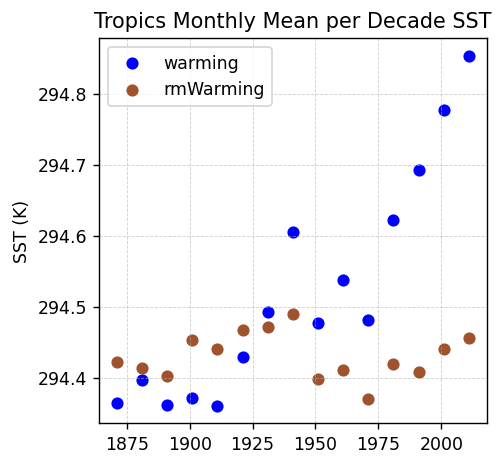

In [110]:
# plot SST
fig, ax = plt.subplots(figsize=(4,4), dpi=125)
ax.scatter(decades, decade_meansGW, color='blue', label=f"warming")
ax.scatter(decades, decade_meansNW, color='sienna', label=f"rmWarming")

ax.set_title(f"Tropics Monthly Mean per Decade SST")

ax.set_ylabel(f"SST (K)")
ax.legend()
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

### Potential Intensity Analysis

In [ ]:
import xarray as xr
import os
import fnmatch
import time

# PI netcdf naming: "YYYY0101.atmos_month.PI.nc"

def PIpathname(GW, ennum, year):
    if GW == 1:
        PIpath = "WARMING_PI_PATH"
    elif GW == 0:
        PIpath = "NONWARMING_PI_PATH"
    return PIpath

In [9]:
'''
lat_filter = 'tropics' OR 'all' (default all latitudes)
year_filter = desired year ranges OR 'all' (default all years)
'''

def PI_decmeans(GW, lat_filter, year_filter):
    # set parameters
    if GW == 1:
        fenum = 9
    elif GW == 0:
        fenum = 11
    
    ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(6,fenum)]
    
    # apply year filter
    if year_filter != 'all':
        yearranges = year_filter
    else:
        decades = np.arange(1871, 2021, 10)
        yearranges = [np.arange(year, year+10) for year in decades] #15 total decades
      
    # store decadal average PIs in decade_means
    decade_means = np.zeros(len(yearranges))
    
    i = 0
    for decade in yearranges:
        print(f"decade: {decade}")
        st_time = time.time()
        
        decmean = 0
        for ennum in ennums:
            print(f"ennum: {ennum}")
            for year in decade:
                if year == 2020 and GW == 1:
                    continue
                pathname = PIpathname(GW, ennum, year)
                filtered_ds = xr.open_dataset(pathname)
                # apply latitude filter
                if lat_filter != 'all':
                    #filtered_ds = xr.concat([filtered_ds.sel(grid_yt=slice(-30,-10)), filtered_ds.sel(grid_yt=slice(10,30))], dim="grid_yt")
                    filtered_ds = filtered_ds.sel(grid_yt=slice(10,30))
                    print(f"{filtered_ds['grid_yt'].values}")
                decmean += filtered_ds['vmax'].mean()
                
                if year == 1871:
                    print(f"{pathname}")
        
        # calculate decade mean
        if year == 2020 and GW == 1:
            decmean = decmean / ((len(yearranges[0])-1)*len(ennums))
        else:
            decmean = decmean / (len(yearranges[0])*len(ennums))
        
        decade_means[i] = decmean
        print(f"decmean: {decmean}")
        i += 1
        
        end_time = time.time()
        print(f"time elapsed for load(): {end_time-st_time}")
        print("")
        
    return decade_means

#### checks

In [10]:
def plot_xrda(dataarray, title):
    fig, ax = plt.subplots(figsize=(8,3), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

    dataarray.plot(ax=ax, transform=ccrs.PlateCarree())
    ax.gridlines(draw_labels=['bottom', 'left'], ls=':')
    ax.coastlines()
    ax.set_title(f"{title}")

In [11]:
def realign_sstda(filtered_ds, sst_ds, plottimeJ, plottimeN):
    filtered_da = filtered_ds['To'].sel(time=plottimeJ)
    sst_da = sst_ds['sst'].sel(time=plottimeN, method='nearest')
    
    # rename coordinate values
    filtered_da = filtered_da.rename({"grid_xt": "lon", "grid_yt": "lat"})
    
    # realign output & SST datasets
    sst_da = sst_da.interp_like(filtered_da, method='nearest')

    return sst_da

In [12]:
pathname = PIpathname(0, '06', 1881)
filtered_ds = xr.open_dataset(pathname)

sst_ds = xr.open_dataset(forcing_SSTs['NW'])
post1870 = cftime.DatetimeNoLeap(1880, 12, 31)
sst_ds = sst_ds.sel(time = sst_ds.time > post1870)

'\n# plot 3\nfig, ax1 = plt.subplots(figsize=(8,3), subplot_kw={\'projection\': ccrs.PlateCarree(central_longitude=180)})\n\nsst_ds.sel(time=plottimeN, method=\'nearest\')[\'sst\'].plot(ax=ax1, transform=ccrs.PlateCarree())\nax1.gridlines(draw_labels=[\'bottom\', \'left\'], ls=\':\')\nax1.coastlines()\nax1.set_title(f"SST @{str(post1870)}")\n'

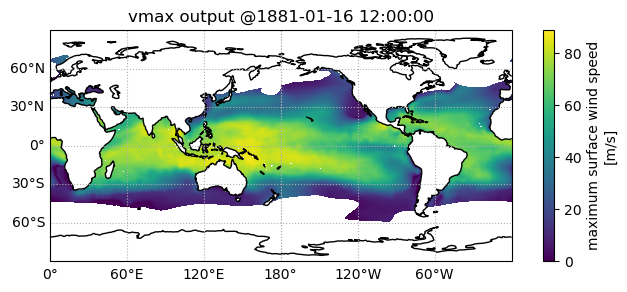

In [13]:
# plot filtered_ds and sst_ds
import xarray as xr
import matplotlib, matplotlib.pyplot as plt
import cartopy, cartopy.crs as ccrs

plottimeJ = cftime.DatetimeJulian(1881, 1, 16, 12, 0, 0, 0, has_year_zero=False)
plottimeN = cftime.DatetimeNoLeap(1881, 1, 16)


# plot 1
fig, ax = plt.subplots(figsize=(8,3), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

filtered_ds.sel(time=plottimeJ)['vmax'].plot(ax=ax, transform=ccrs.PlateCarree())
ax.gridlines(draw_labels=['bottom', 'left'], ls=':')
ax.coastlines()
ax.set_title(f"vmax output @{str(plottimeJ)}")

'''
# plot 3
fig, ax1 = plt.subplots(figsize=(8,3), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

sst_ds.sel(time=plottimeN, method='nearest')['sst'].plot(ax=ax1, transform=ccrs.PlateCarree())
ax1.gridlines(draw_labels=['bottom', 'left'], ls=':')
ax1.coastlines()
ax1.set_title(f"SST @{str(post1870)}")
'''

Text(0.5, 1.0, 'calculated vmax @1881-01-16 12:00:00')

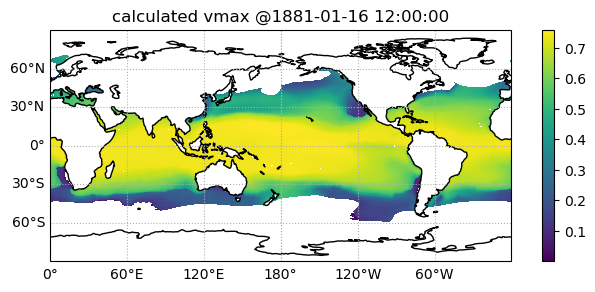

In [15]:
# calculate PI
filtered_da = filtered_ds['To'].sel(time=plottimeJ)
sst_da = sst_ds['sst'].sel(time=plottimeN, method='nearest')

# rename coordinate values
filtered_da = filtered_da.rename({"grid_xt": "lon", "grid_yt": "lat"})

# realign output & SST datasets
sst_da = sst_da.interp_like(filtered_da, method='nearest')

# plot
testdiff = (sst_da-filtered_da)/filtered_da
testdiff = np.sqrt(testdiff)

fig, ax1 = plt.subplots(figsize=(8,3), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

testdiff.plot(ax=ax1, transform=ccrs.PlateCarree())
ax1.gridlines(draw_labels=['bottom', 'left'], ls=':')
ax1.coastlines()
ax1.set_title(f"calculated vmax @{str(plottimeJ)}")

#### collect manual PI data

In [33]:
# decadal avg of (element-wise) PI manual calculations

def get_manualPI(GW, lat_filter):
    decades = np.arange(1871, 2021, 10)
    yearranges = [np.arange(year, year+10) for year in decades] #15 total decades
    yearPIs = []
    
    # store decadal average PIs in decade_means
    decade_means = np.zeros(len(yearranges))
    manual_decmeans = np.zeros(len(yearranges))
    
    if GW == 1:
        fenum = 9
        pathS = forcing_SSTs['GW']
    elif GW == 0:
        fenum = 11
        pathS = forcing_SSTs['NW']
    
    ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(6,fenum)]
    dict_calcPI = {}
    
    i = 0
    print(f"GW={GW}")
    for decade in yearranges:
        st_time = time.time()
    
        manual_decmean = 0 # keep track of manually calculated pi per decade
        
        for year in decade:
            if year == 2020 and GW == 1: # no data for this year
                continue
            # 1. get filtered_da from all ennums
            for ennum in ennums:
                pathname = PIpathname(GW, ennum, year)
                if ennum == "06":
                    filtered_ds = xr.open_dataset(pathname)
                else:
                    new_ds = xr.open_dataset(pathname)
                    filtered_ds = xr.concat([filtered_ds, new_ds], dim='time')
            
            # 2. get sst_da
            idx = year2index(GW, year, year+1)
            assert len(idx) == 12
            SST_ds = xr.open_dataset(pathS)
            sst_ds = SST_ds.isel(time=idx)
            
            # apply latitude filter to datasets
            if lat_filter != 'all':
                filtered_ds = xr.concat([filtered_ds.sel(grid_yt=slice(-30,-10)), filtered_ds.sel(grid_yt=slice(10,30))], dim="grid_yt")
                sst_ds = xr.concat([sst_ds.sel(lat=slice(-30,-10)), sst_ds.sel(lat=slice(10,30))], dim="lat")
    
            # 3a. get To and SST data arrays
            filtered_da = filtered_ds['To']
            sst_da = sst_ds['sst']
    
            # 3b. standardize data arrays to match coords & resolution
            filtered_da = filtered_da.rename({"grid_xt": "lon", "grid_yt": "lat"}) # rename coords to match
            # increase sst_da resolution thru interpolation
            convtimes = [cftime.DatetimeNoLeap(time.year, time.month, time.day, time.hour, time.minute, time.second) for time in filtered_da['time'].values] # convert filtered_da times to sst_da compatible time objects
            sst_da = sst_da.interp(lat=filtered_da['lat'], lon=filtered_da['lon'], time=convtimes, method='linear', kwargs={"fill_value": "extrapolate"})
    
            # 3c. cos weighting (ME with 85)
            filtered_da = filtered_da*np.cos(filtered_da['lat']*np.pi/180)
            sst_da = sst_da*np.cos(sst_da['lat']*np.pi/180)
    
            # 4. calculate PI manually
            s = sst_da.mean(dim="time")
            to = filtered_da.mean(dim="time")
            pi2 = (s-to)/to #PI squared
            pi = np.sqrt(pi2)
            
            # store global avg PI data array & value from this year
            dict_calcPI[year] = pi
            avgpi = pi.mean().item() # global avg PI value
            manual_decmean += avgpi
            yearPIs.append(avgpi)
    
            #print(f"{year}:\n avg to={avgto}\n sst={avgsst}")
            #print(f"PI={avgpi}\n")
            
            end_time = time.time()
        
        list_calcPI = dict_calcPI.values()
        avg_calcPI = xr.concat(list_calcPI, dim="time")
        #avg_calcPI = avg_calcPI*np.cos(avg_calcPI['lat']*np.pi/180) # add cos weighting before averaging (ME with 63-64)
        avg_calcPI = avg_calcPI.mean(dim='time')
    
        # store decadal average
        decade_means[i] = avg_calcPI.mean()
        if year == 2020 and GW == 1: # no data for this year
            manual_decmeans[i] = manual_decmean/9
        else:
            manual_decmeans[i] = manual_decmean/10
        i += 1
        
        print(f"time elapsed for year: {end_time-st_time}")
        print("")
        
        return dict_calcPI, decade_means, manual_decmeans

In [30]:
# decadal avg of (element-wise) PI manual calculations
GW = 0
lat_filter = 1


decades = np.arange(1871, 2021, 10)
yearranges = [np.arange(year, year+10) for year in decades] #15 total decades
yearPIs = []

# store decadal average PIs in decade_means
decade_means = np.zeros(len(yearranges))
manual_decmeans = np.zeros(len(yearranges))

if GW == 1:
    fenum = 9
    pathS = forcing_SSTs['GW']
elif GW == 0:
    fenum = 11
    pathS = forcing_SSTs['NW']

ennums = [f"0{i}" if i < 10 else f"{i}" for i in range(6,fenum)]
dict_calcPI = {}

i = 0
print(f"GW={GW}")
for decade in yearranges:
    st_time = time.time()

    manual_decmean = 0 # keep track of manually calculated pi per decade
    
    for year in decade:
        if year == 2020 and GW == 1: # no data for this year
            continue
        # 1. get filtered_da from all ennums
        for ennum in ennums:
            pathname = PIpathname(GW, ennum, year)
            if ennum == "06":
                filtered_ds = xr.open_dataset(pathname)
            else:
                new_ds = xr.open_dataset(pathname)
                filtered_ds = xr.concat([filtered_ds, new_ds], dim='time')
        
        # 2. get sst_da
        idx = year2index(GW, year, year+1)
        assert len(idx) == 12
        SST_ds = xr.open_dataset(pathS)
        sst_ds = SST_ds.isel(time=idx)
        
        # apply latitude filter to datasets
        if lat_filter != 'all':
            filtered_ds = xr.concat([filtered_ds.sel(grid_yt=slice(-30,-10)), filtered_ds.sel(grid_yt=slice(10,30))], dim="grid_yt")
            sst_ds = xr.concat([sst_ds.sel(lat=slice(-30,-10)), sst_ds.sel(lat=slice(10,30))], dim="lat")

        # 3a. get To and SST data arrays
        filtered_da = filtered_ds['To']
        sst_da = sst_ds['sst']

        # 3b. standardize data arrays to match coords & resolution
        filtered_da = filtered_da.rename({"grid_xt": "lon", "grid_yt": "lat"}) # rename coords to match
        # increase sst_da resolution thru interpolation
        convtimes = [cftime.DatetimeNoLeap(time.year, time.month, time.day, time.hour, time.minute, time.second) for time in filtered_da['time'].values] # convert filtered_da times to sst_da compatible time objects
        sst_da = sst_da.interp(lat=filtered_da['lat'], lon=filtered_da['lon'], time=convtimes, method='linear', kwargs={"fill_value": "extrapolate"})

        # 3c. cos weighting (ME with 108)
        filtered_da = filtered_da*np.cos(filtered_da['lat']*np.pi/180)
        sst_da = sst_da*np.cos(sst_da['lat']*np.pi/180)

        # 4.' calculate PI manually
        s = sst_da.mean(dim="time")
        to = filtered_da.mean(dim="time")
        pi2 = (s-to)/to #PI squared
        pi = np.sqrt(pi2)
        
        # store global avg PI data array & value from this year
        dict_calcPI[year] = pi
        avgpi = pi.mean().item() # global avg PI value
        manual_decmean += avgpi
        yearPIs.append(avgpi)

        #print(f"{year}:\n avg to={avgto}\n sst={avgsst}")
        #print(f"PI={avgpi}\n")
        
        end_time = time.time()
    
    list_calcPI = dict_calcPI.values()
    avg_calcPI = xr.concat(list_calcPI, dim="time")
    #avg_calcPI = avg_calcPI*np.cos(avg_calcPI['lat']*np.pi/180) # add cos weighting before averaging (ME with 67-68)
    avg_calcPI = avg_calcPI.mean(dim='time')

    # store decadal average
    decade_means[i] = avg_calcPI.mean()
    if year == 2020 and GW == 1: # no data for this year
        manual_decmeans[i] = manual_decmean/9
    else:
        manual_decmeans[i] = manual_decmean/10
    i += 1
    
    print(f"time elapsed for year: {end_time-st_time}")
    print("")
    
    #plot_xrda(avg_calcPI, f"calculated PI @{decade[0]}-{decade[-1]}")

GW=0
time elapsed for year: 52.51933717727661

time elapsed for year: 51.465699195861816

time elapsed for year: 54.27204728126526

time elapsed for year: 58.926740407943726

time elapsed for year: 68.57756805419922

time elapsed for year: 62.03272032737732

time elapsed for year: 56.64129853248596

time elapsed for year: 55.75991868972778

time elapsed for year: 55.57284474372864

time elapsed for year: 58.456995725631714

time elapsed for year: 64.54793095588684

time elapsed for year: 77.36061716079712

time elapsed for year: 55.35309195518494

time elapsed for year: 54.48918676376343

time elapsed for year: 53.77367949485779



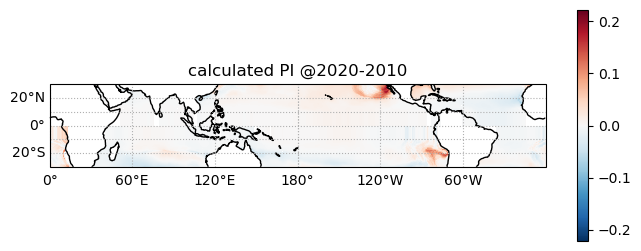

In [31]:
# differential maps
yr = 2020

plot_xrda(dict_calcPI[yr]-dict_calcPI[yr-10], f"calculated PI @{yr}-{yr-10}")

#### timeplot

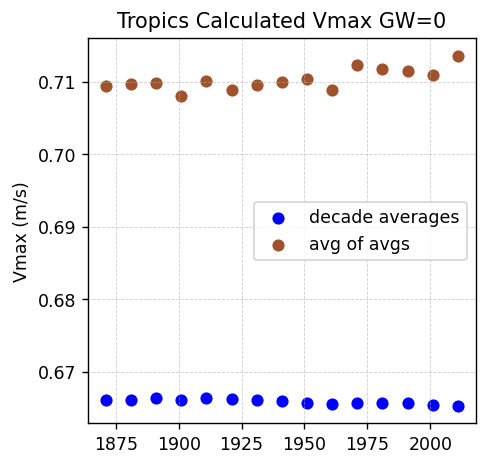

In [63]:
fig, ax = plt.subplots(figsize=(4,4), dpi=125)
ax.scatter(decades, decade_means, color='blue', label=f"decade averages")
ax.scatter(decades, manual_decmeans, color='sienna', label=f"avg of avgs")

ax.set_title(f"Tropics Calculated Vmax GW={GW}")

ax.set_ylabel(f"Vmax (m/s)")
ax.legend()
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

#### PI histograms

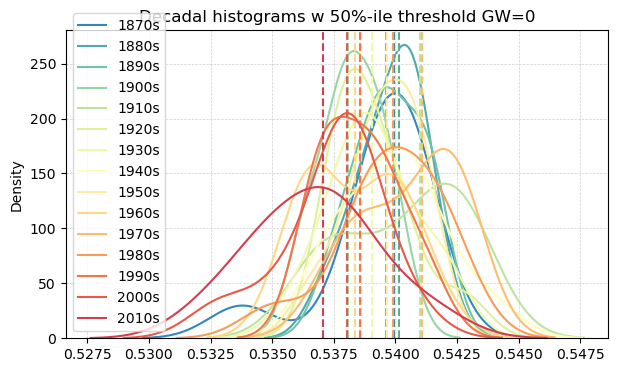

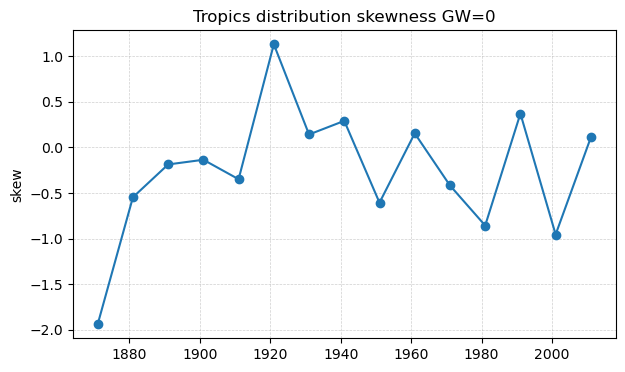

In [55]:
pct = 50 # specify desired percentile
stats = np.zeros(len(decades)) # store percentile stat
skews = np.zeros(len(decades)) # store skew

# histogram of PI values
fig, ax = plt.subplots(figsize=(7,4)) # histograms
for i in range(len(decades)):
    data = yearPIs[(10*i):(10*i)+10]
    sns.kdeplot(data=data, cumulative=False, ax=ax, label=f"{decades[i]-1}s", color=colors[i])
    #ax.hist(yearPIs[(10*i):(10*i)+10], label=decades[i], color=colors[i])

    # measure skewness
    skews[i] = skew(np.array(data))
    
    # calculate stat for vertical line
    stats[i] = np.percentile(data, pct)
    ax.axvline(stats[i], color=colors[i], linestyle='--') # plot vertical line

ax.set_title(f"Decadal histograms w {pct}%-ile threshold GW={GW}")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.legend()

# plot stat over time
'''
#fig, ax1 = plt.subplots(figsize=(7,4)) # plot percentiles
ax1.scatter(decades, stats)
ax1.set_title(f"{pct}%-ile threshold GW={GW}")
ax1.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
'''

# plot skew over time
fig, ax2 = plt.subplots(figsize=(7,4)) # plot skews
ax2.plot(decades, skews, marker='o')
ax2.set_title(f"Tropics distribution skewness GW={GW}")
ax2.set_ylabel(f"skew")
ax2.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')

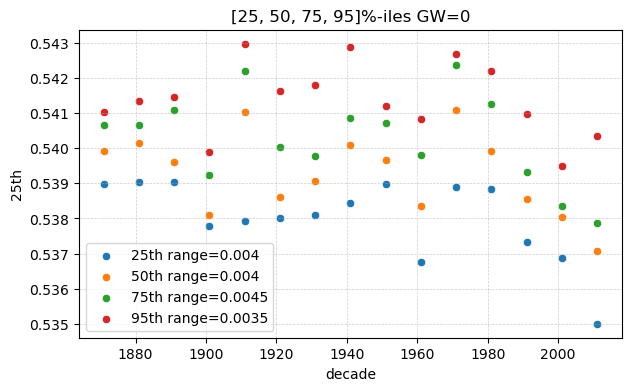

In [56]:
# multiple percentiles
pct = [25, 50, 75, 95] # specify desired percentile
stats = [] # store percentile stat

pct_names = [f"{percent}th" for percent in pct]
col_names = pct_names.copy()
col_names.append('decade')

decades = np.arange(1871, 2021, 10)

# histogram of PI values
fig, ax = plt.subplots(figsize=(7,4)) # histograms

for i in range(len(decades)):
    tempdict = {}
    tempdict['decade'] = decades[i]
    data = yearPIs[(10*i):(10*i)+10]

    # calculate stat for vertical line
    percentiles = np.percentile(data, pct)
    for j in range(len(pct_names)):
        tempdict[col_names[j]] = percentiles[j]
    stats.append(tempdict)

stats_df = pd.DataFrame(stats)

# plot
for pth in pct_names:
    rg = np.ptp(stats_df[pth]) # find range
    sns.scatterplot(data=stats_df, x='decade', y=pth, ax=ax, label=f"{pth} range={round(rg,4)}")
    
ax.set_title(f"{pct}%-iles GW={GW}")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.legend()

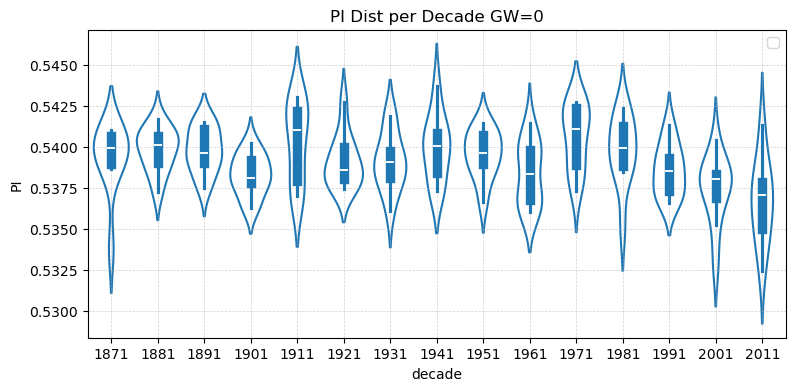

In [57]:
# violin plots
list_dict = [] # list to convert into dataframe

# collect data
for i in range(len(decades)):
    data = yearPIs[(10*i):(10*i)+10]

    for point in data:
        tempdict = {}
        tempdict['decade'] = decades[i]
        tempdict['PI'] = point
        list_dict.append(tempdict)

stats_df = pd.DataFrame(list_dict)

# plot
fig, ax = plt.subplots(figsize=(9,4))
sns.violinplot(data=stats_df, x="decade", y="PI", fill=False, ax=ax, width=0.9) # violin plots
ax.set_title(f"PI Dist per Decade GW={GW}")
ax.grid(alpha=0.6, linestyle='--', linewidth=0.5, which='both')
ax.legend()